<a href="https://colab.research.google.com/github/fernandovidalnn/evaluacion_1_mineria_datos/blob/main/ev2_mineria_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación 1 EDA Mineria de datos**


Integrantes:
* Fernando Vidal
* Matías Gallardo

[LINK FUENTE DE DATOS](https://www.kaggle.com/datasets/anbudanadithya/spotify-music)

https://www.kaggle.com/datasets/anbudanadithya/spotify-music

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [ ]:
df = pd.read_csv('Spotify_Music.csv')

In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
#pd.set_option('display.max_rows', None)

In [ ]:
df.shape # visualizamos la cantidad de filas y columnas

(114000, 21)

In [ ]:
df.head() #Visualizacion de las primeras 5 filas

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.tail() # visualización de las ultimas 5 filas

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [ ]:
df.dtypes #vemos el tipo de dato de cada columna

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
 # Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de Unnamed: 0 = 0
Total de valores nulos de track_id = 0
Total de valores nulos de artists = 1
Total de valores nulos de album_name = 1
Total de valores nulos de track_name = 1
Total de valores nulos de popularity = 0
Total de valores nulos de duration_ms = 0
Total de valores nulos de explicit = 0
Total de valores nulos de danceability = 0
Total de valores nulos de energy = 0
Total de valores nulos de key = 0
Total de valores nulos de loudness = 0
Total de valores nulos de mode = 0
Total de valores nulos de speechiness = 0
Total de valores nulos de acousticness = 0
Total de valores nulos de instrumentalness = 0
Total de valores nulos de liveness = 0
Total de valores nulos de valence = 0
Total de valores nulos de tempo = 0
Total de valores nulos de time_signature = 0
Total de valores nulos de track_genre = 0


Podemos ver que contamos con un dataset casi completamente limpio y existe 1 nulo en 3 columanas distintas (artists, album_name y track_name) el resto de columnas no contienen nulos.

Realizaremos una aliminacion completa de los nulos.

In [ ]:
df = df.dropna() #eliminacion de nulos completa y agresiva

confirmaremos la eliminación de los nulos.

In [ ]:
 # Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de Unnamed: 0 = 0
Total de valores nulos de track_id = 0
Total de valores nulos de artists = 0
Total de valores nulos de album_name = 0
Total de valores nulos de track_name = 0
Total de valores nulos de popularity = 0
Total de valores nulos de duration_ms = 0
Total de valores nulos de explicit = 0
Total de valores nulos de danceability = 0
Total de valores nulos de energy = 0
Total de valores nulos de key = 0
Total de valores nulos de loudness = 0
Total de valores nulos de mode = 0
Total de valores nulos de speechiness = 0
Total de valores nulos de acousticness = 0
Total de valores nulos de instrumentalness = 0
Total de valores nulos de liveness = 0
Total de valores nulos de valence = 0
Total de valores nulos de tempo = 0
Total de valores nulos de time_signature = 0
Total de valores nulos de track_genre = 0


Aplicamos dropna y eliminamos los nulos presentes que al finalizar vemos que era solo 1 fila que contenia 3 nulos en 3 columnas distintas

Revisaremos con cuantas filas quedó el df luego de la eliminación de los nulos

In [ ]:
df.shape # filas y columnas

(113999, 21)

Revisaremos la cantidad de categorias únicas por cada columna

In [ ]:
df.nunique() #categorias única por cada columna

,0
Unnamed: 0,113999
track_id,89740
artists,31437
album_name,46589
track_name,73608
popularity,101
duration_ms,50696
explicit,2
danceability,1174
energy,2083


El resultaod de nunique muestra la cantidad de valores únicos por cada columna, permitiendo identificar variables categoricas (como explicit y mode) y aquellas con alta variabilidad como track_id o track_name. Esto nos ayuda a entender la estructura de los datos.

A continuación se revisaran algunas variables categoricas de interés mediante el conteo de sus valores, con el fin de identificar su distribucion y posibles patrones

In [ ]:
df['explicit'].value_counts() # contamos cada categoria de la columna explicit en este caso True/False

,count
explicit,
False,104252
True,9747


La variable explicit presenta un claro desbalance, donde la gran mayoria de las canciones no sn explicitas, mientras que aproximadamente el 9% corresponde a explícitas

In [ ]:
df['mode'].value_counts() # contamos la frecuencia de cada categoria dentro de mode

,count
mode,
1,72681
0,41318


La variable mode indica la escala musical (1:mayor, 0:menor). Se observa predominio del modo mayor lo que suguiere una tendencia hacia canciones de caracter alegre

In [ ]:
df['key'].value_counts() # contamos la frecuencia de cada categoria dentro de key

,count
key,
7,13244
0,13061
2,11644
9,11313
1,10772
5,9368
11,9282
4,9008
6,7921


la variable key representa la tonalidad musical de las canciones, codificada numéricamente del 0 al 11. al analizar su distribucion, se observa que algunas tonalidades son más frecuentes que otras, destacando principalmente la tonalidad G SOL (7) Y el C DO (0)

In [ ]:
df['time_signature'].value_counts() # contamos la frecuencia de cada categoria en time_signature

,count
time_signature,
4,101842
3,9195
5,1826
1,973
0,163


la variable time_signature indica el compas musical de las canciones. Se observa un claro predominio del valor 4 (compas 4/4), con más de 100.000 registros, lo que evidencia que la gran mayoria de las canciones siguen una estructura rítmica estándar. Otros compases como 3 y 5 aparecen en menor proporción.

In [ ]:
df['track_genre'].value_counts().head(10) # cuenta las categorias dentro de track_genre

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


La variable track_genre (indica el genero de la cancion) presenta una distribucion balanceada donde cada genero contiene aproximadamente 1000 registros.

Visualizaremos agrupando los datos por género (track_genre) y calcularemos el promedio de polularidad de cada uno, mostrando ordenadamente los géneros más populares primero.

In [ ]:
df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
...,...
chicago-house,12.339000
detroit-techno,11.174000
latin,8.297000


Al analizar la popularidad promedio por género musical, se observa que existen diferencias significativas entre ellos. Géneros como pop-film y k-pop presentan los mayores niveles de popularidad promedio, mientras que géneros como iranian, romance y latin presentan los valores más bajos.

Esto indica claramente que no todos los géneros tienen el mismo nivel de aceptación o reproducción en la plataforma, evidenciando preferencias claras hacia ciertos estilos musicales.

In [ ]:
df.columns # devuelve los nombres de todas las columnas del df

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

# **MAPEO DE DATOS**

## **Mapeo de variables del dataset Spotify**

- **Unnamed: 0:** Numérico Discreto (corresponde a un indice no aporta valor analitico)
- **track_id:** Categórico Nominal (identificador único)
- **artists:** Categórico Nominal
- **album_name:** Categórico Nominal
- **track_name:** Categórico Nominal

- **popularity:** Numérico Discreto (escala de 0 a 100)
- **duration_ms:** Numérico Continuo (tiempo en milisegundos)

- **explicit:** Categórico Binario (variable booleana: True/False)

- **danceability:** Numérico Continuo
- **energy:** Numérico Continuo

- **key:** Categórico Nominal (representa la tonalidad musical)
- **loudness:** Numérico Continuo (decibelios)
- **mode:** Categórico Binario (0 = menor, 1 = mayor)

- **speechiness:** Numérico Continuo
- **acousticness:** Numérico Continuo
- **instrumentalness:** Numérico Continuo
- **liveness:** Numérico Continuo
- **valence:** Numérico Continuo

- **tempo:** Numérico Continuo (BPM)
- **time_signature:** Categórico Discreto (compás musical)

- **track_genre:** Categórico Nominal

---

## **Clasificación de Variables**

### 🔹 Categórico Nominal
Categorías sin un orden o jerarquía específica.  
Ejemplo: `track_id`, `artists`, `track_genre`.

### 🔹 Categórico Ordinal
Categorías que siguen un orden lógico o escala.  
Ejemplo: niveles de popularidad agrupados (baja, media, alta).

> Nota: Aunque `key` tiene un orden técnico musical, en análisis de datos se trata como categórico nominal.

### 🔹 Numérico Discreto
Valores que provienen de conteo y no admiten decimales en su unidad base.  
Ejemplo: `popularity`.

### 🔹 Numérico Continuo
Valores que provienen de mediciones y pueden tomar valores en un rango continuo.  
Ejemplo: `danceability`, `energy`, `loudness`, `tempo`, `duration_ms`.



Generamos un resumen estadistico completo del df incluyendo todas las columnas numericas y categoricas

In [ ]:
df.describe(include='all') # resumen estadistico incluyendo todas las columnas

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,113999.000000,113999,113999,113999,113999,113999.000000,1.139990e+05,113999,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999
unique,NaN,89740,31437,46589,73608,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,NaN,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,NaN,9,279,195,151,NaN,NaN,104252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,56999.421925,NaN,NaN,NaN,NaN,33.238827,2.280312e+05,NaN,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,NaN
std,32909.243463,NaN,NaN,NaN,NaN,22.304959,1.072961e+05,NaN,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,8.586000e+03,NaN,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,28499.500000,NaN,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,NaN
50%,56999.000000,NaN,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,85499.500000,NaN,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


la variable speechiness (presencia de hablar) (con mediana 0.0489) presentan valores muy bajos, lo que indica que las canciones contienen poca presencia de voz hablada (como podcasts o discursos)

la variable instrumentalness (con mediana cercana a 0) indica que la mayoria de las canciones no son instrumentales, es decir, incluyen voz.

la variable energy (con media 0.64) presenta valores relativamente altos, lo que refleja que predominan canciones con alta intesidad y dinamismo

la variable duration_ms (con media 228.000 ms) corresponde a la duracion de las canciones en milisegundos, lo que equivale aproximadamente a 3.8 minutos, un valor tipoco en musica comercial.

En conjunto podemos decir que predominan canciones vocales energéticas y de duracion promedio cercana a los 4 minutos

Visualizaremos un histograma de todas las columnas númericas del df

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'danceability'}>],
       [<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>],
       [<Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>],
       [<Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'time_signature'}>, <Axes: >]],
      dtype=object)

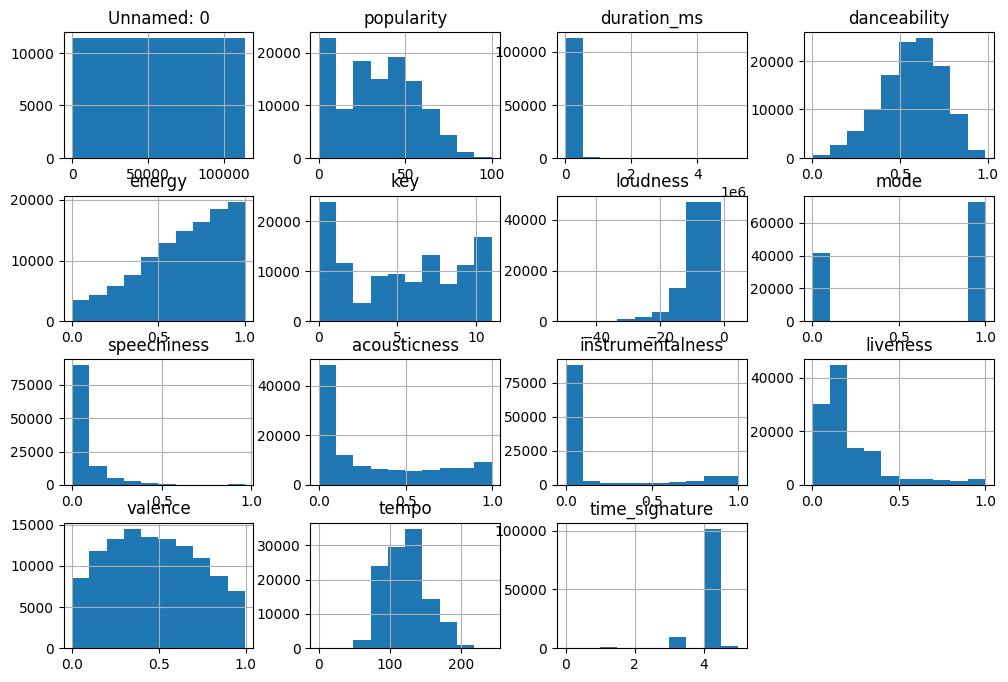

In [ ]:
df.hist(figsize=(12,8)) # generamos histogramas de las columnas numericas del df

El análisis de histogramas muestra que la mayoria de las variables presentan distribuciones concentradas en rangos especificos, evidenciando patrones claros en las características musicales del df.

En general predominan canciones vocales(se deduce de speechiness y instrumentalness), energéticas(desde energy) y con ritmos moderados(desde tempo), con presencia de outliers principalmente en la duración(desde duration_ms).

---
acontinuación, se analizará la distribución de las variables numericas mediante histogramas, con el objetivo de identificar patrones, concentracion de datos y posibles valores atipicos.

In [ ]:
cols_numericas = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

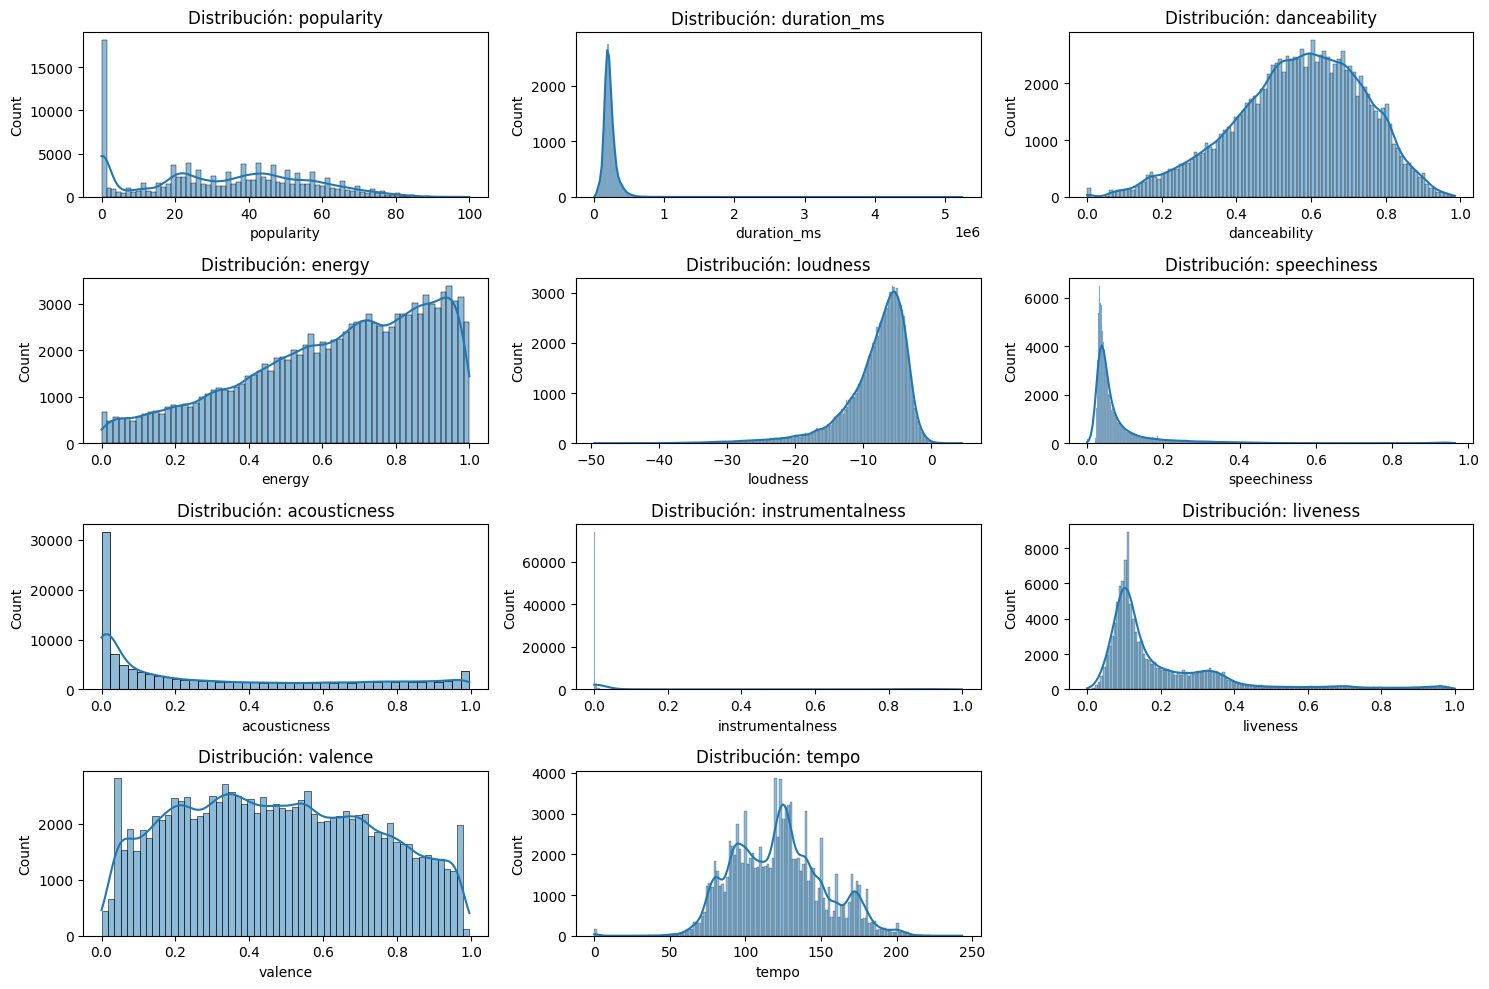

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

## PATRONES
* Se observa claramente en energy una tendencia a
los valores altos
* danceability tiene una distribución de tipo normal
* templo con una concentracion aprox en 100-140 BPM

Esto demuestra que hay patrones en el comportamiento de las canciones

## CONCENTRACIÓN DE DATOS
* speechiness: concentrado cerca de 0
* instrumentalness: casi todo en 0
* acousticness:fuerte acumulación en valores bajos

Se identifica donde estan concentrados los datos

## VALORES ATIPICOS
En duration_ms se ve una cola larga a la derecha en donde se puede deducir que existen valores atípicos

El analisis de histogramas de las columnas nos permite observar la distribución de las variables númericas evidenciando que la mayoria de las canciones presentan valores bajos en caracteristicas como speechiness e instrumentalness, mientras que variables como energy y danceability muestran una mayor dispersión. Esto suguiere que predominan canciones energeticas y con ritmos moderados

---
Realizaremos un bloxplot con las variables númericas nos servira para detectar la distribución de los datos, mediana, rango y outliers

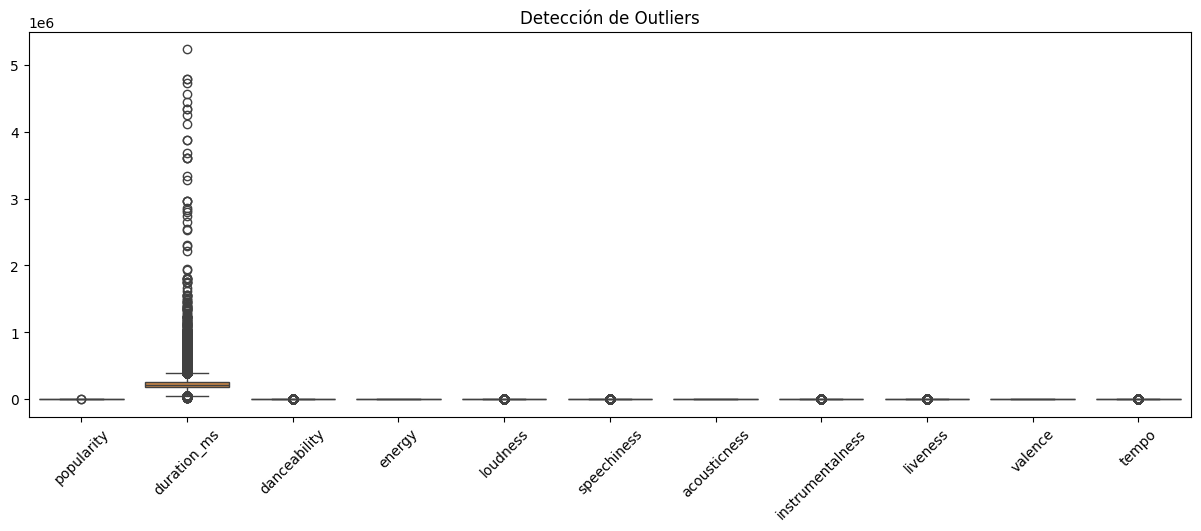

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[cols_numericas])
plt.xticks(rotation=45)
plt.title('Detección de Outliers')
plt.show()

La variable duration_ms presenta numerosos outliers y una escala mayor que el resto, lo que distorsiona la visualización. Las demás variables muestran menor dispersión aunque esta no se parecia claramente debido a la diferencia entre duration_ms y las otras variables

Por esta razón, se decide analizar nuevamente los diagramas exluyendo esta variable, con el fin de obtener una mejor interpretación del resto de los datos.

Realizaremos los mismos boxplot pero excluyendo a duration_ms para poder visualizarlos mejor

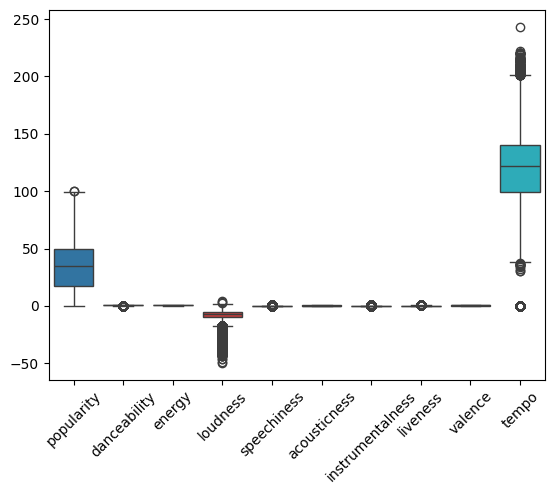

In [ ]:
cols_sin_duration = [col for col in cols_numericas if col != 'duration_ms']

sns.boxplot(data=df[cols_sin_duration])
plt.xticks(rotation=45)
plt.show()

Al excluir la variable duration_ms, se observa con mayor claridad la distribución y dispersión del resto de las variables, permitiendo un mejor analisis y comparación entre ellas

En general, las variables presentan una distribución relativamente concentrada y estable, con algunos valores atípicos principalmente en loudness y tempo.

Aun así no se logra apreciar con claridad todos los diagramas, por esta razon lo haremos por separado.

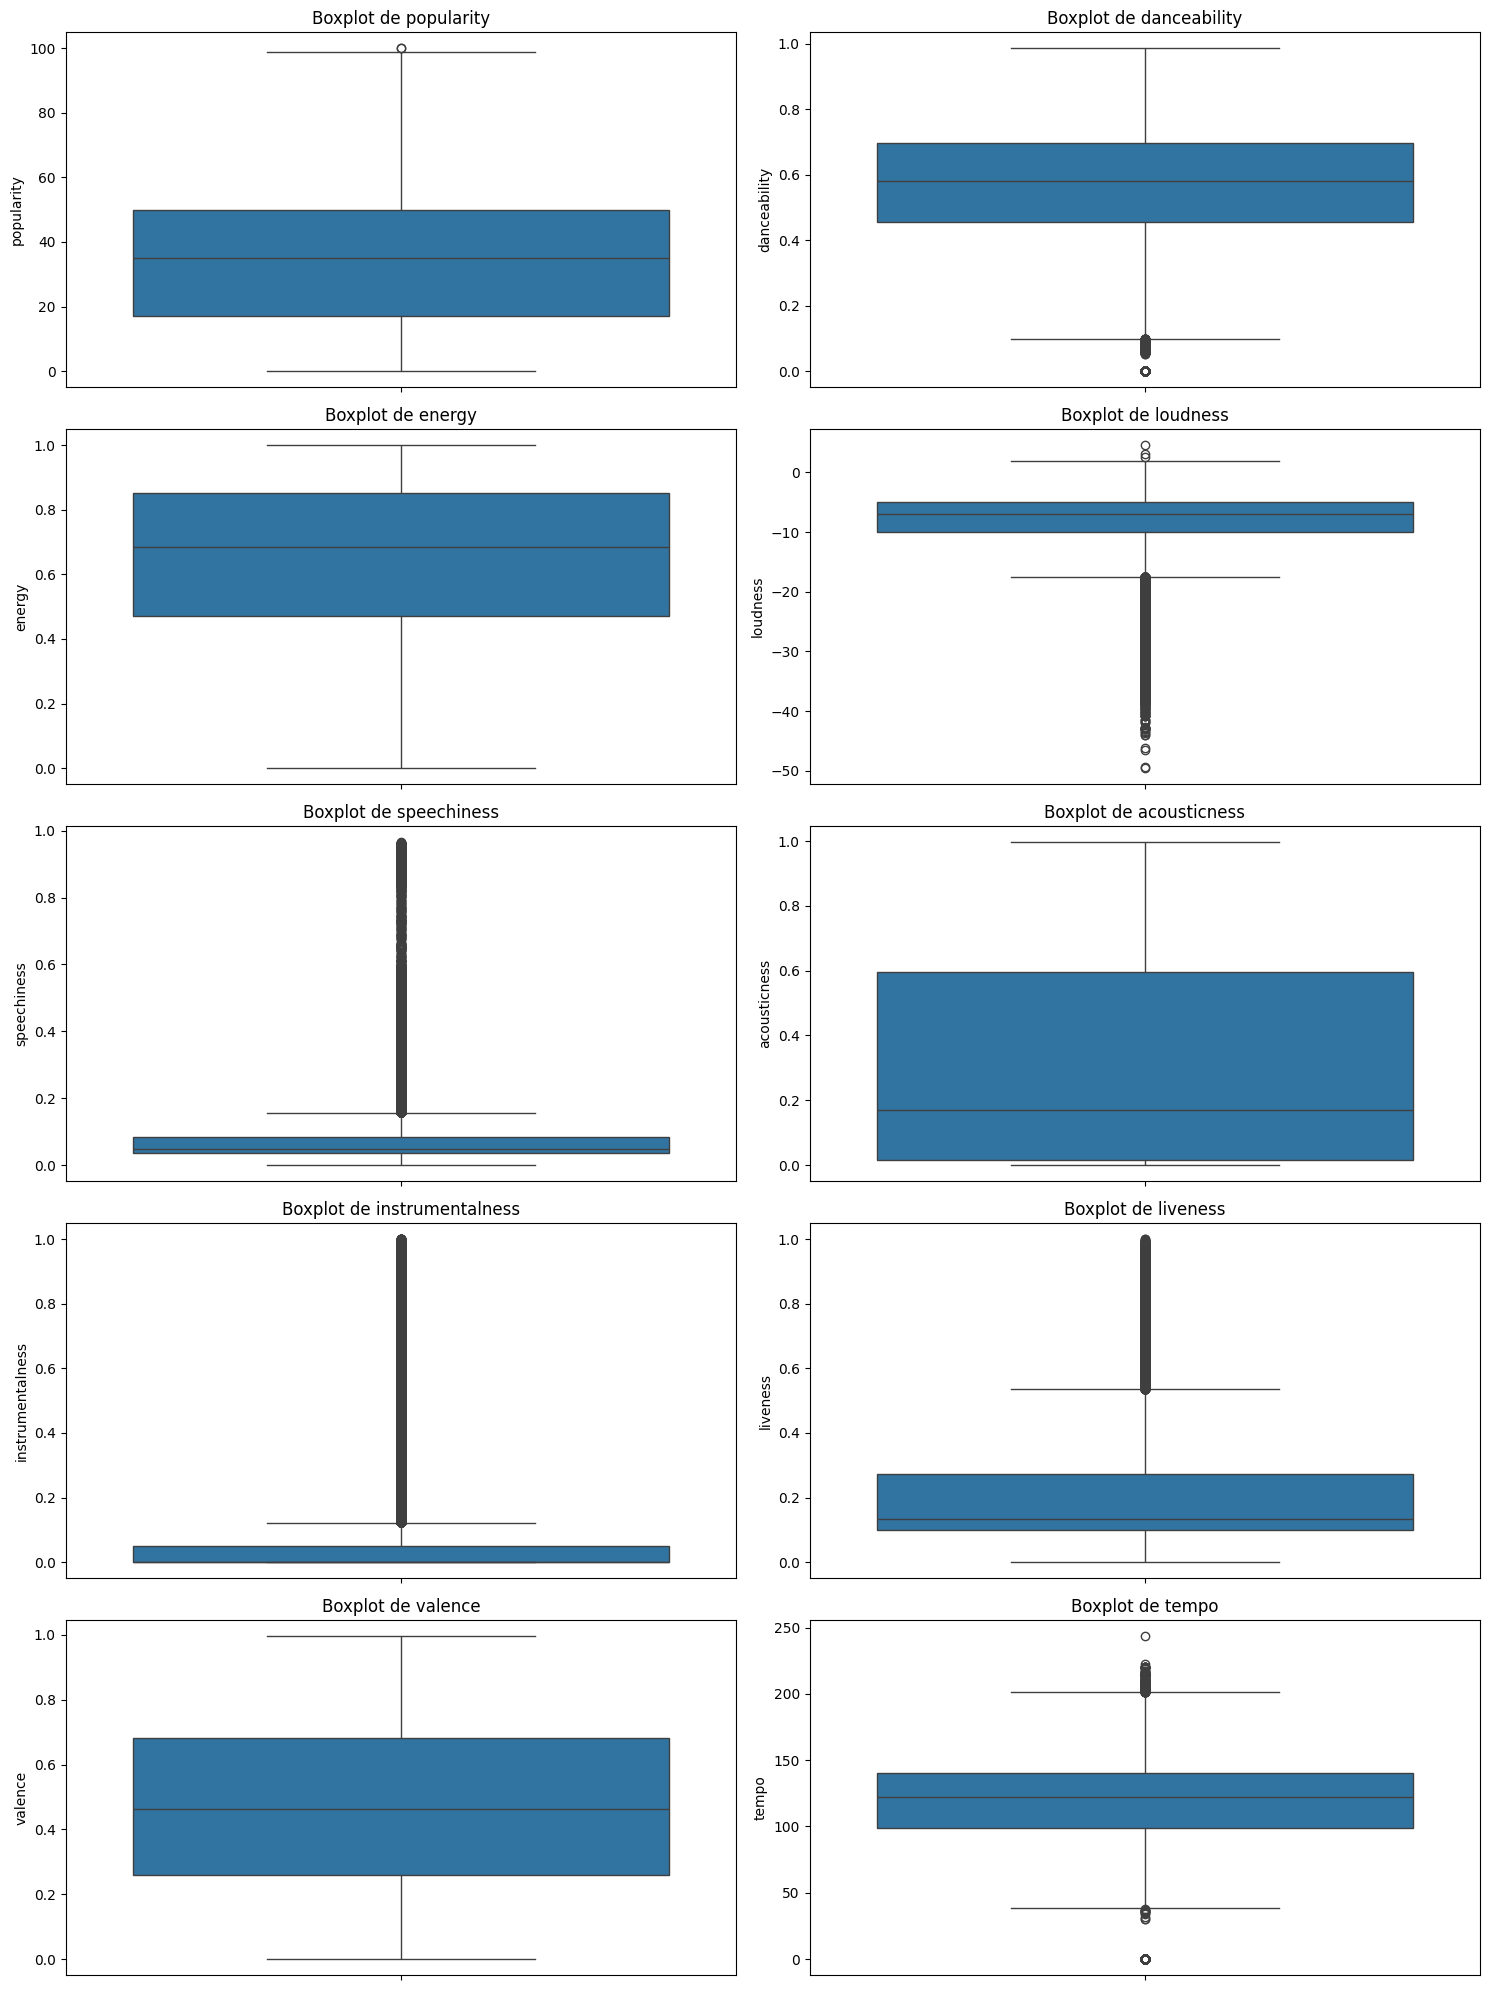

In [ ]:
plt.figure(figsize=(15, 20))

for i, col in enumerate(cols_sin_duration, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

El análisis de los diagramas de caja individuales evidencia que variables como speechiness, instrumentalness y acousticness presentan distribuciones sesgadas hacia valores bajos, indicando predominio de canciones vocales y no acústicas. Por otro lado, variables como danceability, energy y valence muestran una distribución más equilibrada, reflejando variabilidad en características musicales. Asimismo, se observan valores atípicos en variables como loudness y tempo, lo que evidencia diversidad en la intensidad sonora y el ritmo de las canciones. En general, los outliers detectados responden a la naturaleza del dataset y no necesariamente a errores en los datos.

---

# Analisis de la popularidad con otras variables

A continuación, se realizaran diversos graficos con el fin de encontrar relaciones con la categoria de popularidad con el resto de categorias.

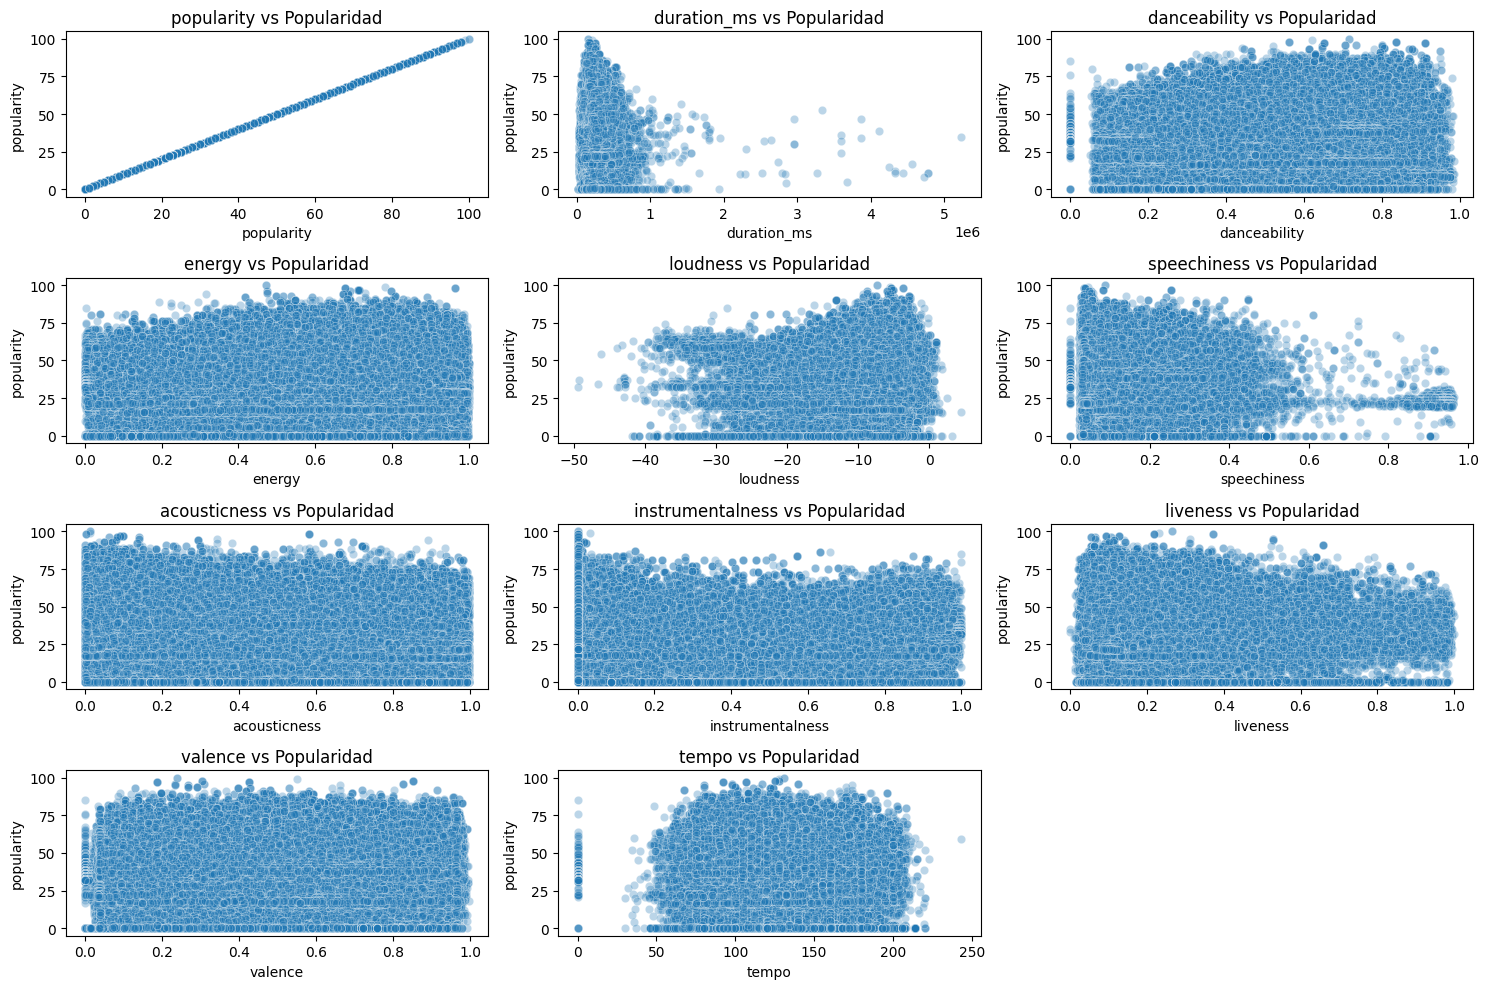

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    sns.scatterplot(x=df[col], y=df['popularity'], alpha=0.3)
    plt.title(f'{col} vs Popularidad')

plt.tight_layout()
plt.show()

Este conjunto de gráficos de dispersión permite analizar la relación entre cada una de las variables numéricas del dataset y la popularidad de las canciones. En cada gráfico, el eje horizontal representa una característica musical (como energía, tempo o danceability), mientras que el eje vertical corresponde a la popularidad. Cada punto representa una canción individual, lo que permite observar la distribución completa de los datos.

El objetivo principal de este gráfico es identificar posibles patrones o tendencias entre las variables. Por ejemplo, si los puntos tienden a formar una pendiente ascendente, podría sugerir que a mayor valor de la característica, mayor popularidad. Por el contrario, una nube de puntos dispersa sin forma clara indica que no existe una relación evidente. Este análisis es fundamental ya que ayuda a detectar qué variables podrían ser relevantes y cuáles probablemente no aporten información significativa.

Al analizar los gráficos de dispersión, se observa que no existe una relación lineal clara entre las variables musicales y la popularidad, ya que la mayoría presenta una alta dispersión sin patrones definidos. Variables como danceability, energy y valence se distribuyen a lo largo de todos los niveles de popularidad, mientras que speechiness e instrumentalness se concentran en valores bajos sin evidenciar impacto directo. En general, estos resultados indican que la popularidad no depende de una sola característica, sino de múltiples factores externos al dataset.

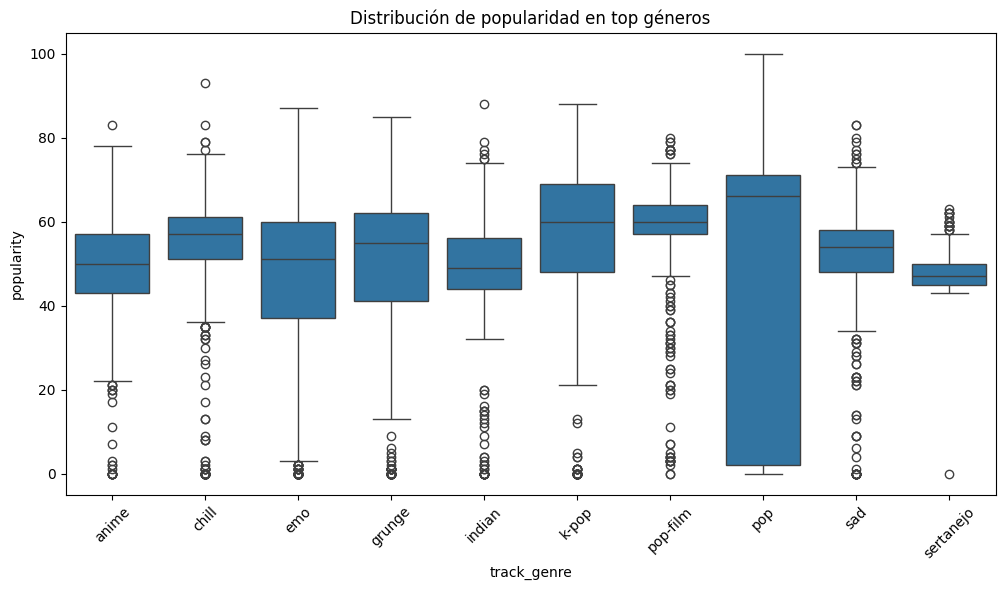

In [ ]:
# Diagrama de cajas entre la popularidad y los géneros que estan en el top de popularidad
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

top_genres = genre_popularity.head(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df['track_genre'].isin(top_genres)],
    x='track_genre',
    y='popularity'
)

plt.xticks(rotation=45)
plt.title('Distribución de popularidad en top géneros')
plt.show()

El diagrama de cajas complementa el análisis anterior mostrando la distribución completa de la popularidad para los géneros más relevantes. A diferencia del promedio, este gráfico permite observar la mediana, los cuartiles y la presencia de valores atípicos.

Esto es importante porque dos géneros pueden tener promedios similares pero comportamientos muy distintos. Por ejemplo, un género puede tener una popularidad estable (valores concentrados), mientras que otro puede presentar alta variabilidad con algunas canciones extremadamente populares. Este gráfico permite evaluar la consistencia de cada género y entender mejor cómo se distribuye la popularidad dentro de ellos.

Al analizar la distribución de la popularidad en los principales géneros musicales, se observan diferencias tanto en la mediana como en la dispersión de los datos. Géneros como pop, k-pop y pop-film tienden a presentar medianas más altas, lo que indica una mayor popularidad general, mientras que otros como indian o sertanejo muestran valores más bajos y menos variabilidad. Además, algunos géneros presentan una mayor dispersión y presencia de valores atípicos, lo que sugiere que dentro de un mismo género pueden coexistir canciones muy populares con otras de bajo rendimiento. En conjunto, aunque existen ciertas diferencias entre géneros, estas no son lo suficientemente marcadas como para afirmar que el género por sí solo determina la popularidad.

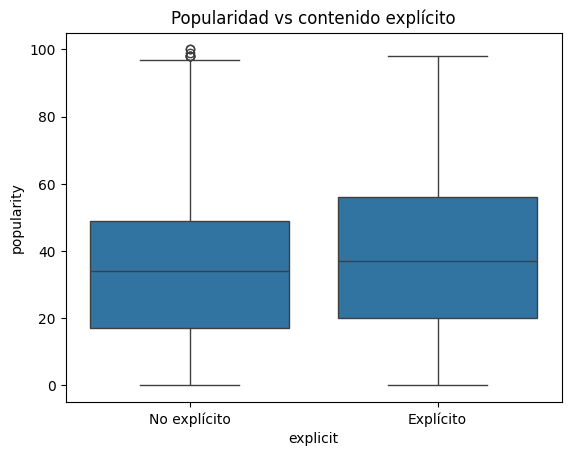

In [ ]:
# Diagrama de cajas entre la popularidad y el contenido explícito
sns.boxplot(x=df['explicit'], y=df['popularity'])
plt.title('Popularidad vs contenido explícito')
plt.xticks([0, 1], ['No explícito', 'Explícito'])
plt.show()

Este gráfico compara la distribución de la popularidad entre canciones explícitas y no explícitas. Se utiliza un diagrama de cajas para visualizar diferencias en la mediana, la dispersión y la presencia de valores extremos en ambos grupos.

El objetivo es evaluar si el contenido explícito tiene algún impacto en la popularidad. Por ejemplo, si las canciones explícitas presentan una mediana más alta, podría sugerir que este tipo de contenido está asociado a mayor éxito. Sin embargo, si las distribuciones son similares, indicaría que esta variable no tiene un efecto significativo.

Al analizar la relación entre la popularidad y el contenido explícito, se observa que ambas categorías presentan distribuciones bastante similares, sin diferencias marcadas en la mediana ni en la dispersión de los datos. Aunque las canciones explícitas muestran levemente una mayor mediana de popularidad, esta diferencia no es significativa, y en ambos casos existen valores altos y bajos de popularidad. En conjunto, estos resultados indican que el contenido explícito no tiene un impacto claro o determinante en la popularidad de las canciones.

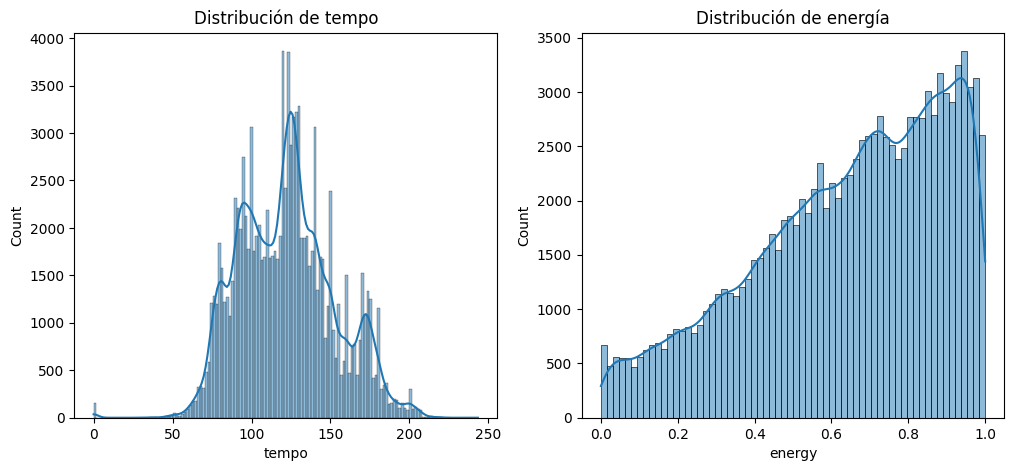

In [ ]:
# Diagramas de distribucion del tempo de las canciones y la energia de las canciones
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['tempo'], kde=True)
plt.title('Distribución de tempo')

plt.subplot(1, 2, 2)
sns.histplot(df['energy'], kde=True)
plt.title('Distribución de energía')

plt.show()

Estos histogramas permiten analizar cómo se distribuyen las variables tempo y energía en el conjunto de datos. El tempo representa la velocidad de la canción (en BPM), mientras que la energía refleja su intensidad o dinamismo.

El análisis de estas distribuciones permite identificar patrones generales, como concentraciones en ciertos rangos, posibles sesgos o presencia de valores extremos. Además, ayuda a entender qué tipo de canciones predominan en el dataset, lo que puede ser útil para interpretar resultados posteriores.

Al analizar la distribución de tempo y energy, se observa que el tempo presenta una concentración clara en rangos intermedios, principalmente entre 100 y 150 BPM, lo que indica que la mayoría de las canciones tiene ritmos moderados, con algunos valores extremos menos frecuentes. Por otro lado, la variable energy muestra una tendencia hacia valores altos, evidenciando que predominan canciones con mayor intensidad o dinamismo. En conjunto, estos resultados sugieren que el dataset está compuesto principalmente por canciones de ritmo medio y alta energía.

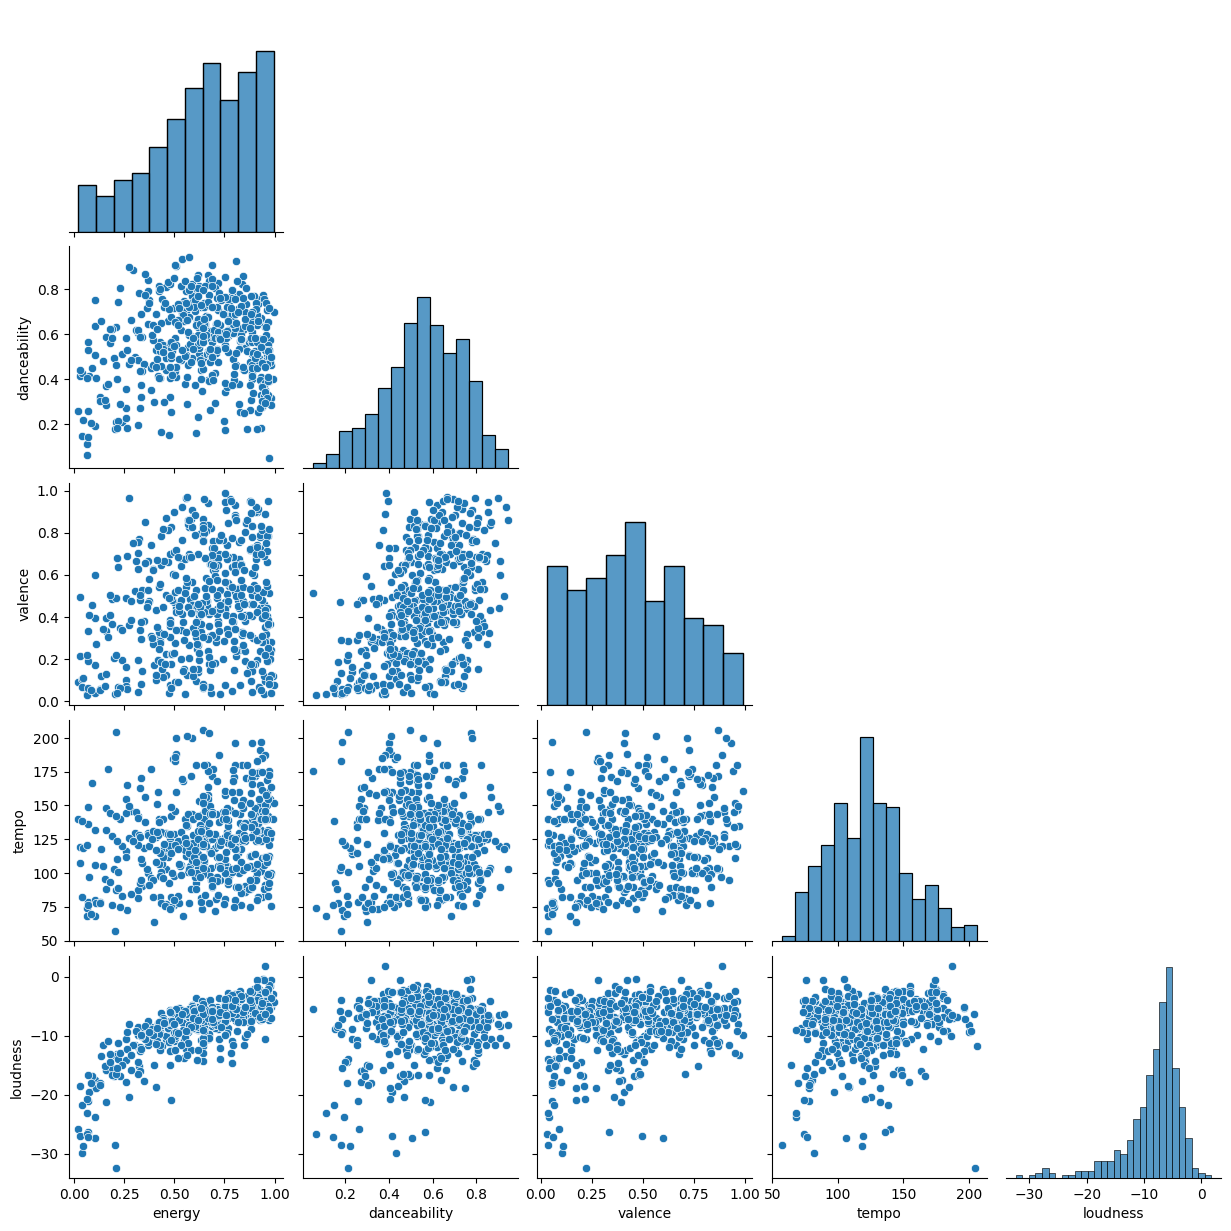

In [ ]:
# Diagrama de relacion entre las variables con un pair plot
sns.pairplot(
    df[['energy', 'danceability', 'valence', 'tempo', 'loudness']].sample(500),
    corner=True
)
plt.show()

El pairplot muestra múltiples gráficos de dispersión entre diferentes pares de variables numéricas, permitiendo observar relaciones de manera simultánea. Además, incluye distribuciones individuales en la diagonal, lo que facilita entender cada variable por separado.

Este tipo de gráfico es útil para detectar patrones más complejos, como relaciones no lineales o agrupamientos de datos. También permite identificar posibles correlaciones entre variables que no son evidentes en análisis individuales. En general, proporciona una visión global de cómo interactúan las características musicales entre sí.

Al analizar el pairplot de las variables musicales, se observa que no existen relaciones lineales fuertes entre la mayoría de ellas, ya que los puntos se distribuyen de forma dispersa. Sin embargo, destaca una relación positiva moderada entre energy y loudness, donde a mayor energía, el volumen tiende a ser menos negativo, lo cual es coherente desde el punto de vista musical. También se aprecia una leve tendencia positiva entre energy y danceability, aunque no es concluyente. Por otro lado, variables como valence y tempo no muestran patrones claros con el resto, lo que sugiere que estas características varían de forma independiente en el dataset. En conjunto, los resultados indican que, si bien existen algunas relaciones esperadas entre variables musicales, la mayoría presenta comportamientos independientes.

In [ ]:
# Tablas de las canciones mas populares y de las canciones menos populares
top_songs = df.sort_values(by='popularity', ascending=False).head(10)
low_songs = df.sort_values(by='popularity', ascending=True).head(10)

print("Top canciones:")
display(top_songs[['track_name', 'artists', 'popularity']])

print("Menos populares:")
display(low_songs[['track_name', 'artists', 'popularity']])

Top canciones:


,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
88410,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
68303,La Bachata,Manuel Turizo,98
89411,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98


Menos populares:


,track_name,artists,popularity
87240,All I Want For Christmas Is My Two Front Teeth,The Platters,0
87194,Winter In My Heart,The Avett Brothers,0
87195,Winter In My Heart,The Avett Brothers,0
87196,Winter In My Heart,The Avett Brothers,0
87260,Everyday,Buddy Holly;The Crickets,0
87234,Winter Wonderland,The Platters,0
87235,Jingle Bell Rock,The Platters,0
87236,All I Want For Christmas Is My Two Front Teeth,The Platters,0
87238,I'll Be Home For Christmas,The Platters,0
87192,Winter In My Heart,The Avett Brothers,0


Estas tablas presentan ejemplos concretos de las canciones con mayor y menor popularidad dentro del dataset. Más allá de los números, permiten observar información contextual como el nombre de la canción y el artista.

Este tipo de análisis es útil para complementar la exploración cuantitativa con ejemplos reales, facilitando la interpretación de los resultados y permitiendo identificar posibles patrones o excepciones.

Al analizar las tablas, se observa que las canciones más populares pertenecen a artistas reconocidos y temas actuales, lo que sugiere influencia de factores externos como la fama y tendencias. En cambio, las menos populares (valor 0) corresponden a canciones menos difundidas y presentan repeticiones, lo que indica posibles duplicados en el dataset. En conjunto, la popularidad no depende solo de las características musicales.

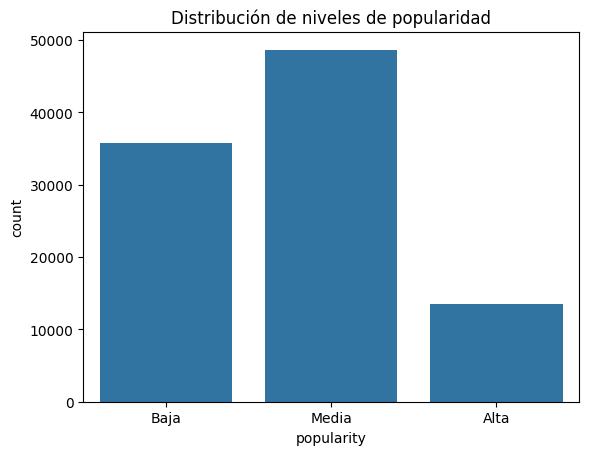

In [ ]:
# Grafico de la distribucion de popularidad por rangos
y_bins = pd.cut(df['popularity'], bins=[0, 30, 60, 100], labels=['Baja', 'Media', 'Alta'])

sns.countplot(x=y_bins)
plt.title('Distribución de niveles de popularidad')
plt.show()

Este gráfico clasifica las canciones en distintos niveles de popularidad (baja, media y alta) y muestra la cantidad de canciones en cada categoría. Esto permite entender cómo está distribuido el target dentro del dataset.

Es especialmente útil para detectar desbalances en los datos, por ejemplo, si la mayoría de las canciones se concentra en un solo rango. Este tipo de información es clave al momento de construir modelos, ya que puede influir en su desempeño.

Al analizar la distribución de los niveles de popularidad, se observa que la mayoría de las canciones se concentra en el rango medio, seguido por el nivel bajo, mientras que las canciones con alta popularidad son considerablemente menos. Esto indica un desbalance en la variable objetivo, donde predominan canciones de popularidad media, lo que puede influir en futuros análisis o modelos.

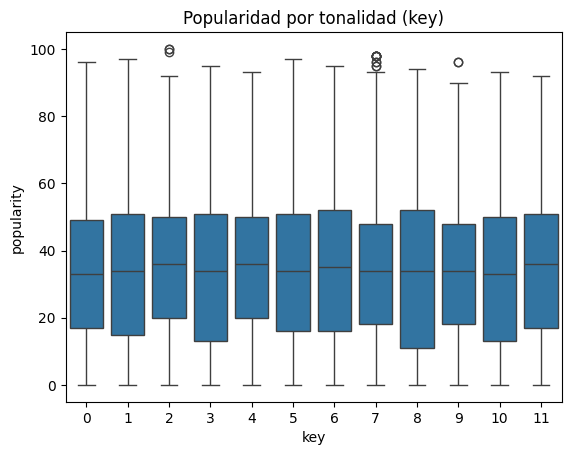

In [ ]:
# Grafico de popularidad por tonalidad
sns.boxplot(x=df['key'], y=df['popularity'])
plt.title('Popularidad por tonalidad (key)')
plt.show()

Este gráfico analiza cómo varía la popularidad según la tonalidad musical de las canciones. Al tratarse de una variable categórica, el boxplot permite comparar la distribución de popularidad entre las distintas tonalidades.

Esto permite evaluar si alguna tonalidad específica está asociada a mayor o menor popularidad, así como observar la variabilidad dentro de cada grupo.

Al analizar la popularidad según la tonalidad (key), se observa que las distribuciones son bastante similares entre todas las categorías, sin diferencias significativas en las medianas ni en la dispersión. Aunque algunas tonalidades presentan valores ligeramente más altos o mayor variabilidad, no se identifica un patrón claro que indique que una tonalidad específica influya en la popularidad. En conjunto, estos resultados sugieren que la tonalidad no es un factor determinante en el nivel de popularidad de las canciones.

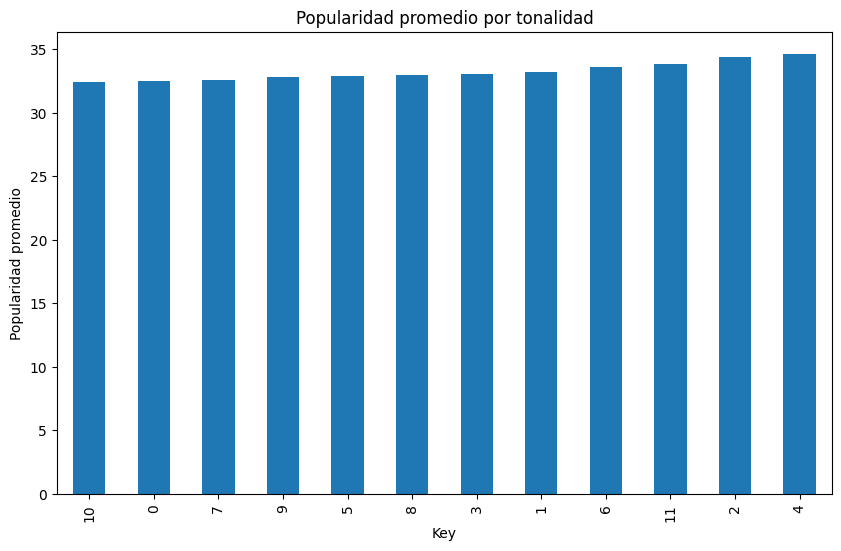

In [ ]:
# Grafico del promedio de tonalidad con popularidad
key_mean = df.groupby('key')['popularity'].mean().sort_values()

plt.figure(figsize=(10, 6))
key_mean.plot(kind='bar')
plt.title('Popularidad promedio por tonalidad')
plt.xlabel('Key')
plt.ylabel('Popularidad promedio')
plt.show()

Este gráfico muestra el promedio de popularidad para cada tonalidad, facilitando una comparación directa entre ellas. A diferencia del boxplot, aquí se pierde información sobre la dispersión, pero se gana claridad en la comparación de valores medios.

Al analizar la popularidad promedio por tonalidad, se observa que los valores son muy similares entre todas las categorías, con diferencias mínimas entre ellas. Aunque algunas tonalidades presentan levemente mayores promedios, estas variaciones no son significativas, lo que refuerza la idea de que la tonalidad no tiene un impacto claro en la popularidad de las canciones.

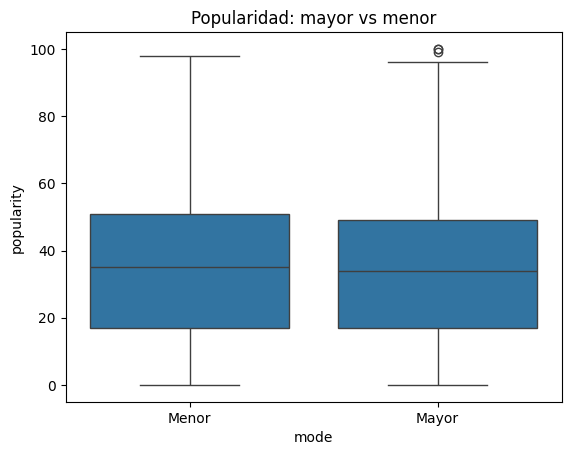

In [ ]:
# Grafico de popularidad vs modo
sns.boxplot(x=df['mode'], y=df['popularity'])
plt.title('Popularidad: mayor vs menor')
plt.xticks([0,1], ['Menor', 'Mayor'])
plt.show()

Este gráfico compara la popularidad entre canciones en modo mayor y menor. Permite observar si existe una diferencia significativa en la distribución de popularidad entre ambos tipos de escala musical.

Al analizar la popularidad según el modo (mayor vs menor), se observa que ambas categorías presentan distribuciones muy similares, con medianas y rangos prácticamente iguales. Aunque el modo mayor muestra levemente valores más altos en algunos casos, la diferencia no es significativa. En conjunto, estos resultados indican que el modo musical no tiene un impacto claro en la popularidad de las canciones.

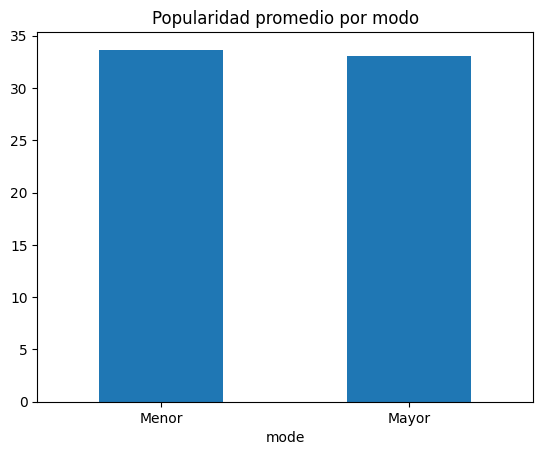

In [ ]:
# Grafico del promedio de modo vs popularidad
df.groupby('mode')['popularity'].mean().plot(kind='bar')
plt.xticks([0,1], ['Menor','Mayor'], rotation=0)
plt.title('Popularidad promedio por modo')
plt.show()

Este gráfico resume la información anterior mostrando el promedio de popularidad para cada modo. Es útil como complemento para una interpretación rápida y directa.

Al analizar la popularidad promedio según el modo, se observa que ambos valores (mayor y menor) presentan promedios muy similares, con diferencias mínimas entre ellos. Esto refuerza la idea de que el modo musical no tiene un impacto significativo en la popularidad de las canciones.

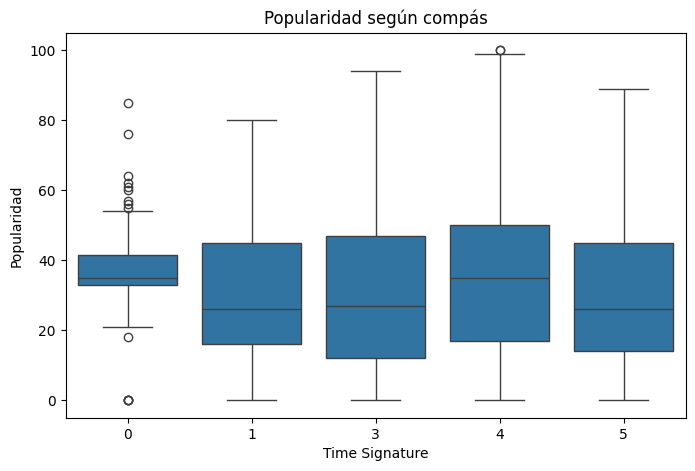

In [ ]:
# Grafico de popularidad vs compás de la canción
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['time_signature'], y=df['popularity'])
plt.title('Popularidad según compás')
plt.xlabel('Time Signature')
plt.ylabel('Popularidad')
plt.show()

Este gráfico analiza la relación entre el compás de la canción y su popularidad. Permite comparar cómo se distribuye la popularidad entre distintos tipos de ritmo.

Al analizar la popularidad según el compás (time_signature), se observa que las distribuciones presentan una alta variabilidad y diferencias en la dispersión entre categorías, aunque sin un patrón claro en las medianas. Algunos compases, como el 4, muestran mayor amplitud y presencia de valores altos, pero estas diferencias no son consistentes. En conjunto, los resultados sugieren que el compás no tiene un impacto determinante en la popularidad de las canciones.

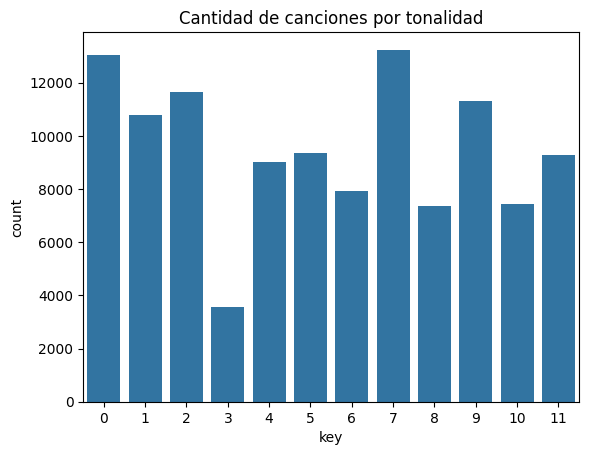

In [ ]:
# Grafico de cantidad de canciones vs su tonalidad
sns.countplot(x=df['key'])
plt.title('Cantidad de canciones por tonalidad')
plt.show()

Este gráfico muestra la cantidad de canciones presentes en cada categoría de tonalidad. Es importante para contextualizar el análisis, ya que una categoría con pocos datos puede generar conclusiones poco confiables.

Al analizar la cantidad de canciones por tonalidad (key), se observa que la distribución no es uniforme, ya que algunas tonalidades, como 0 y 7, concentran una mayor cantidad de canciones, mientras que otras presentan menor frecuencia. Sin embargo, estas diferencias no son extremas, lo que indica una relativa diversidad en las tonalidades del dataset. Este análisis es relevante para contextualizar los resultados, ya que tonalidades con mayor cantidad de datos pueden influir más en los análisis posteriores.

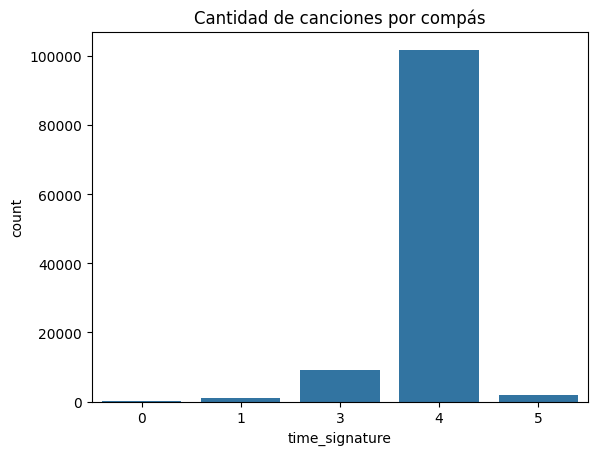

In [ ]:
# Grafico de cantidad de canciones vs su compás
sns.countplot(x=df['time_signature'])
plt.title('Cantidad de canciones por compás')
plt.show()

Este gráfico muestra la cantidad de canciones presentes en cada categoría de compás. Es importante para contextualizar el análisis, ya que una categoría con pocos datos puede generar conclusiones poco confiables.

Al analizar la cantidad de canciones por compás (time_signature), se observa un fuerte desbalance, donde el compás 4 concentra ampliamente la mayoría de las canciones, mientras que los demás compases aparecen con mucha menor frecuencia. Esto indica que la gran parte del dataset sigue la estructura rítmica estándar 4/4, lo cual es coherente con la música comercial actual. Esta distribución es relevante, ya que puede influir en los análisis y limitar la representatividad de los compases menos frecuentes.

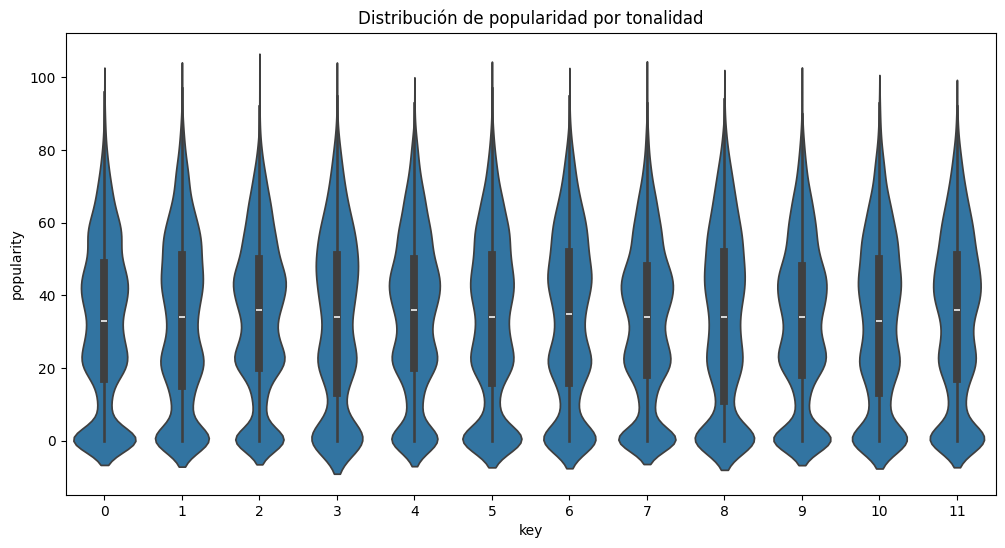

In [ ]:
# Grafico de popularidad vs tonalidad
plt.figure(figsize=(12, 6))
sns.violinplot(x=df['key'], y=df['popularity'])
plt.title('Distribución de popularidad por tonalidad')
plt.show()

El violin plot combina información de densidad y distribución, mostrando no solo los rangos de valores sino también dónde se concentran los datos dentro de cada categoría. Esto proporciona una visión más detallada que el boxplot.

Al analizar la distribución de la popularidad por tonalidad mediante el violin plot, se observa que todas las tonalidades presentan formas muy similares, con concentraciones de datos en rangos parecidos y medianas cercanas entre sí. Aunque existen algunas diferencias en la densidad y presencia de valores extremos, no se identifica un patrón claro que relacione una tonalidad específica con mayores niveles de popularidad. En conjunto, estos resultados refuerzan que la tonalidad no es un factor determinante en la popularidad de las canciones.

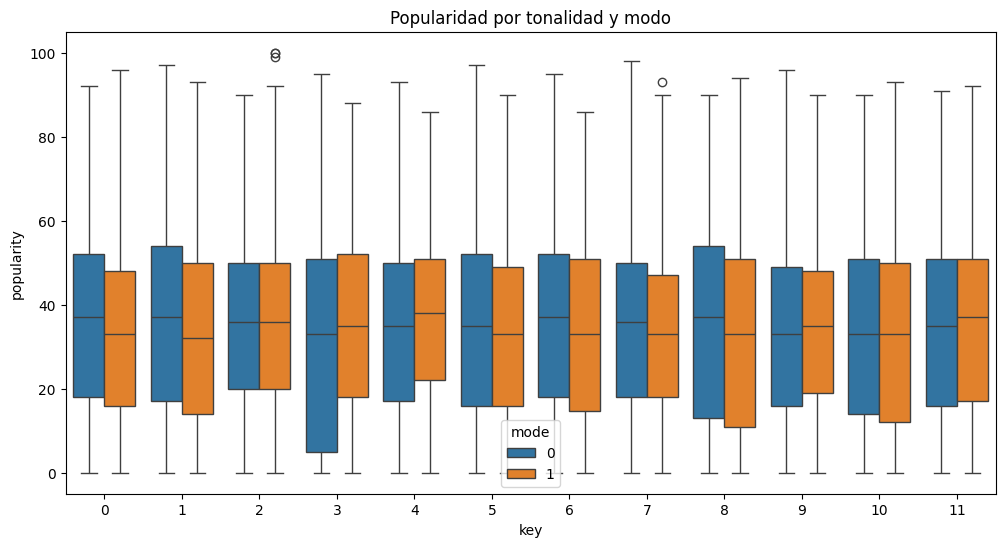

In [ ]:
# Grafico de tonalidad vs modo
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['key'], y=df['popularity'], hue=df['mode'])
plt.title('Popularidad por tonalidad y modo')
plt.show()

Este gráfico permite analizar la interacción entre dos variables categóricas (tonalidad y modo) en relación con la popularidad. Es útil para detectar combinaciones específicas que puedan estar asociadas a distintos niveles de éxito.

Al analizar la popularidad según la tonalidad y el modo, se observa que las distribuciones son muy similares entre ambas categorías en todas las tonalidades, sin diferencias consistentes en las medianas ni en la dispersión. Aunque en algunos casos el modo mayor presenta levemente valores más altos, esta diferencia no se mantiene de forma clara entre todas las tonalidades. En conjunto, los resultados indican que la combinación de tonalidad y modo no tiene un impacto significativo en la popularidad de las canciones.

---

# **MATRIZ CORRELACION**

---
Se aplicará una estandarización a las variables numéricas mediante StandardScaler, con el fin de llevarlas a una escala común (media 0 y desviación estándar 1), permitiendo una mejor comparación y análisis de los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df[cols_numericas])

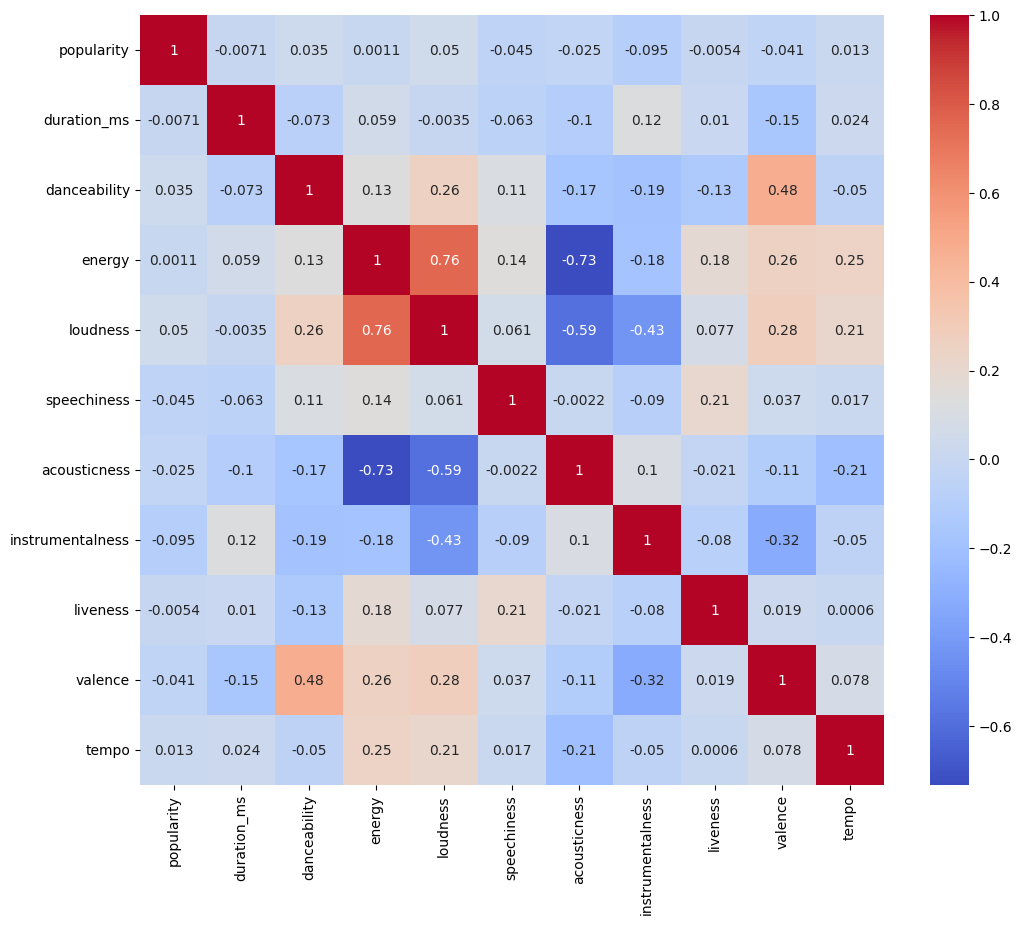

In [ ]:
corr = df_scaled[cols_numericas].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

La matriz de correlación muestra que la variable popularity no presenta correlaciones fuertes con las demás variables, lo queindica que la popularidad de una canción no depende directamente de una sola característica musical

Las variables musicales presentan relaciones lógicas entre sí; sin embargo, ninguna de ellas explica por sí sola la popularidad, lo que sugiere que esta depende de múltiples factores externos como tendencias, artistas o contexto cultural

---
Se amplió el análisis de correlación incorporando variables categóricas binarias como mode y explicit, con el objetivo de evaluar su posible relación con la popularidad y otras características musicales.

In [ ]:
cols_modelo = cols_numericas + ['mode', 'explicit']


In [ ]:
corr = df_scaled[cols_modelo].corr(method='pearson')

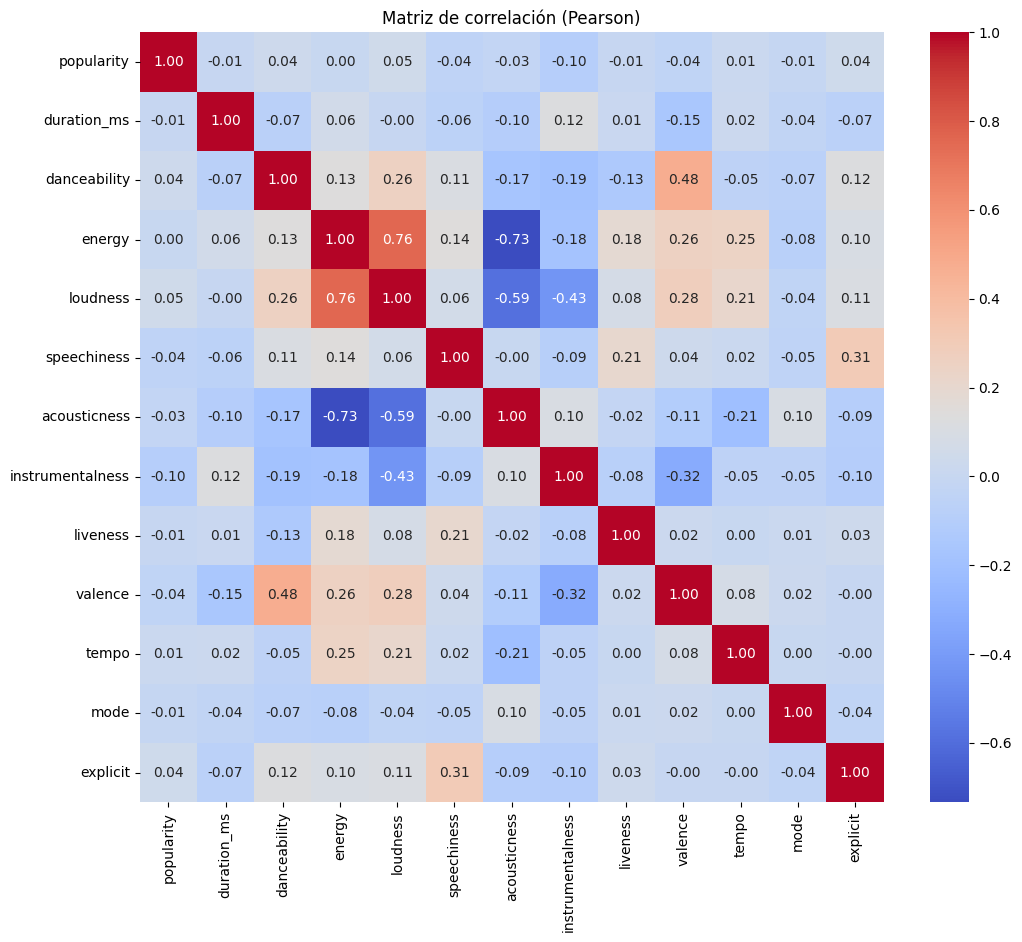

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación (Pearson)")
plt.show()

Al incorporar las variables mode y explicit en la matriz de correlación, se observa que estas tampoco presentan una relación significativa con la variable popularity, ya que sus coeficientes son cercanos a cero.

Sin embargo, se identifica una correlación moderada entre explicit y speechiness (≈ 0.31), lo que sugiere que las canciones explícitas tienden a presentar mayor contenido hablado.

En general, los resultados refuerzan que la popularidad no depende de una sola variable, sino de múltiples factores externos, mientras que las características musicales mantienen relaciones coherentes entre sí.

visualizaremos variables categoricas en graficos.

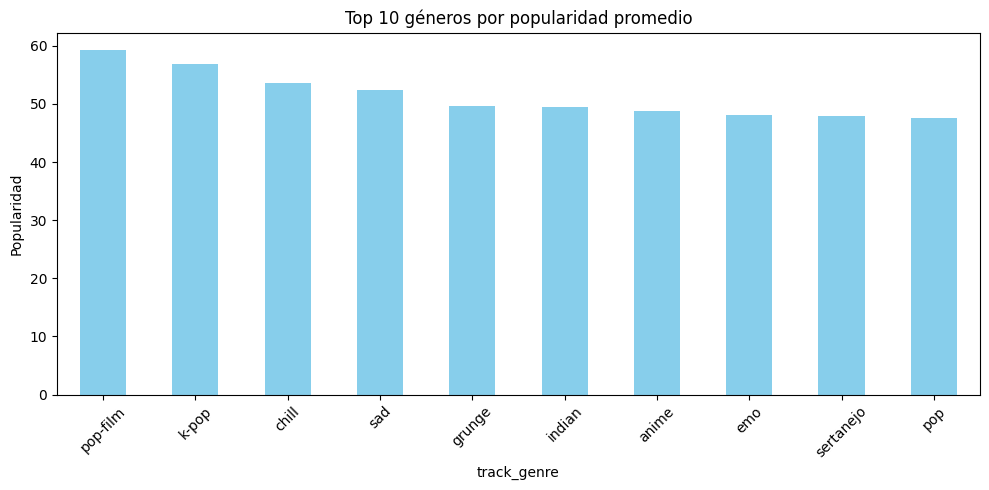

In [ ]:
#agruparemos las canciones por género y calcularemos
#el promedio de popularidad luego mostraremos los 10 generos más populares

top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar', color='skyblue')
plt.title('Top 10 géneros por popularidad promedio')
plt.ylabel('Popularidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico muestra los 10 géneros con mayor popularidad promedio, destacando principalmente pop-film y k-pop como los más populares. Sin embargo, las diferencias entre géneros no son muy amplias, lo que indica que la popularidad se distribuye de manera relativamente equilibrada entre ellos. Esto sugiere que el género musical, por sí solo, no determina completamente la popularidad de una canción.

---
Realizaremos un gráfico de torta que muestra las proporciones de canciones no explícitas y explícitas

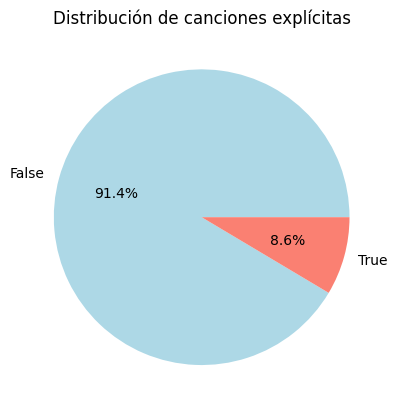

In [ ]:
df['explicit'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightblue', 'salmon']
)

plt.title('Distribución de canciones explícitas')
plt.ylabel('')
plt.show()

El gráfico muestra la distribución de canciones explícitas en el dataset, evidenciando que el 91.4% corresponde a canciones no explícitas, mientras que solo un 8.6% son explícitas. Esto indica un fuerte desbalance en la variable explicit, predominando ampliamente el contenido no explícito.

---

# **ONE HOT ENCODER**

Realizaremos encoder en explicit y track_genre

Crearemos df_model que sera una copia de df original

In [ ]:
df_model = df.copy()

In [ ]:
#one hot encoding
from sklearn.preprocessing import OneHotEncoder


# Inicializar encoder
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Aplicar encoding
encoded = ohe.fit_transform(df_model[['track_genre']])

# Crear DataFrame con nombres de columnas
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['track_genre']))

# Unir al dataframe original
df_model = pd.concat([df_model.drop('track_genre', axis=1), encoded_df], axis=1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

#codificador para variable binaria genera una sola columna (0/1)
ohe_explicit = OneHotEncoder(drop='if_binary', sparse_output=False)

#aplicamos el encoding a explicit
explicit_encoded = ohe_explicit.fit_transform(df_model[['explicit']])

#crearemos un df con los valores codificados y sus nombres de columnas
explicit_df = pd.DataFrame(explicit_encoded, columns=ohe_explicit.get_feature_names_out(['explicit']))

#Eliminamos la columna original y agregamos la version final codificada al df
df_model = pd.concat([df_model.drop('explicit', axis=1), explicit_df], axis=1)

Se aplicó One Hot Encoding a las variables categóricas track_genre y explicit, transformándolas en variables binarias. En el caso de track_genre, se generaron múltiples columnas representando cada categoría, eliminando una de ellas para evitar multicolinealidad. Para la variable explicit, al ser binaria, se utilizó una codificación simplificada que genera una sola columna. Finalmente, las variables originales fueron reemplazadas por sus representaciones codificadas en el dataset.

In [ ]:
df_model.shape #vemos las filas y columnas del df

(114000, 135)

In [ ]:
df_model.head() #visualizamos las primeras filas del df actualizado

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,explicit_False,explicit_True,explicit_nan
0,0.0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.0,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

Se transformaron las variables categóricas a formato numérico mediante encoding, generando nuevas columnas binarias y aumentando la dimensionalidad del dataset.

In [ ]:
# Eliminamos columnas irrrelevantes o no útiles para el análisis y/o modelo
df_model = df_model.drop(columns=[
    'Unnamed: 0',
    'track_id',
    'artists',
    'album_name',
    'track_name'
])

Se eliminaron variables como track_id, artists, album_name y track_name, ya que corresponden a identificadores o variables categóricas de alta cardinalidad que no aportan valor al análisis numérico ni a la matriz de correlación.

In [ ]:
df_model = df_model.drop(columns=['explicit_False'])

df_model = df_model.drop(columns=['explicit_nan'])

In [ ]:
df_model.head() # visualizamos las primeras filas de df tras eliminar esas columnas

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,explicit_True
0,73.0,230666.0,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55.0,149610.0,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57.0,210826.0,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [ ]:
# Seleccionamos las columnas numéricas (int64 y float64) del df
cols_model = df_model.select_dtypes(include=['int64','float64']).columns

In [ ]:
# aplicamos una estandarización a las variables numéricas (media 0, desviacion 1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_model_scaled = df_model.copy()
df_model_scaled[cols_model] = scaler.fit_transform(df_model[cols_model])

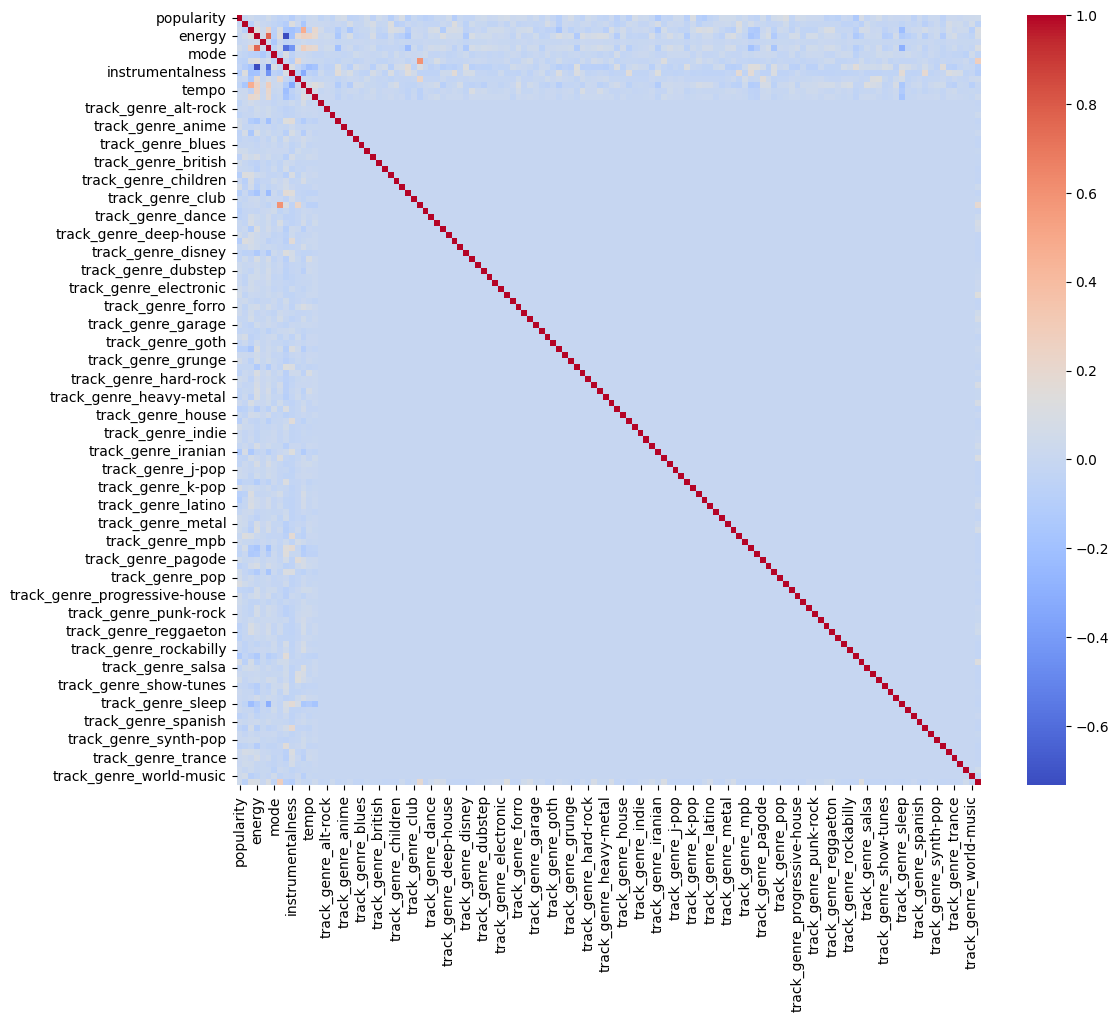

In [ ]:
# Calcula la matriz de correlación y la visualizacion con un mapa de calor
corr_model = df_model_scaled.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_model, cmap='coolwarm')
plt.show()

La matriz de correlación incluye una gran cantidad de variables generadas por el encoding de track_genre, lo que provoca una visualización saturada y poco interpretable. No se observan correlaciones relevantes a simple vista, ya que la mayoría de los valores se concentran cerca de cero.

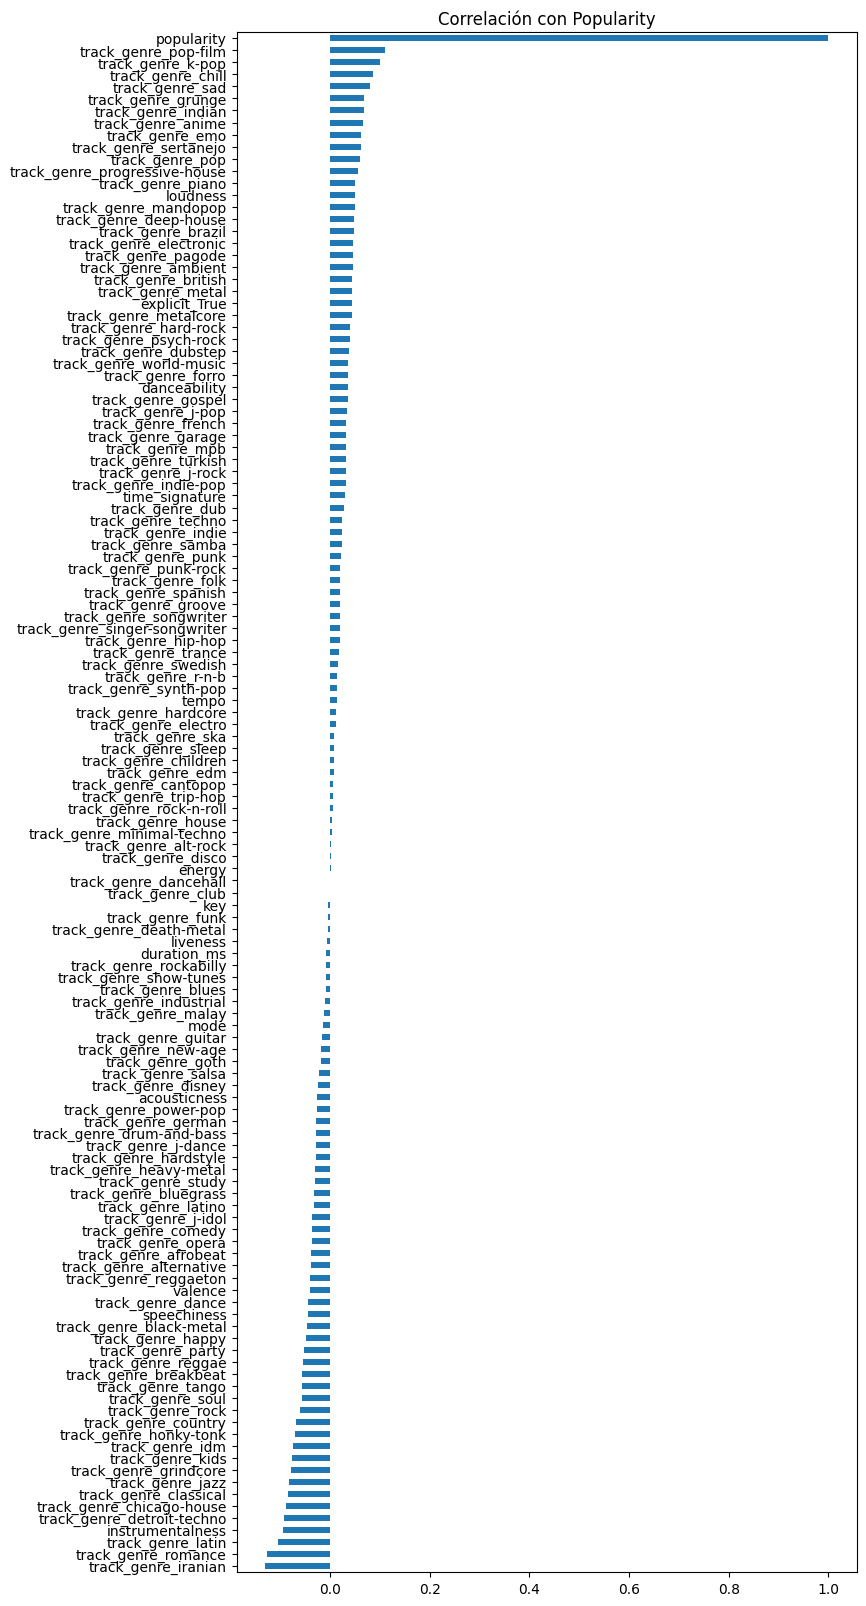

In [ ]:
corr_pop = df_model_scaled.corr()['popularity'].sort_values()

plt.figure(figsize=(8,20))
corr_pop.plot(kind='barh')
plt.title('Correlación con Popularity')
plt.show()

El análisis de correlación con la variable popularity muestra que ninguna de las variables presenta una relación lineal fuerte, ya que los coeficientes se mantienen cercanos a cero. Si bien algunos géneros y características musicales presentan correlaciones levemente positivas o negativas, estas son débiles, lo que indica que la popularidad de una canción no depende de una única variable, sino de múltiples factores, posiblemente externos al dataset analizado.

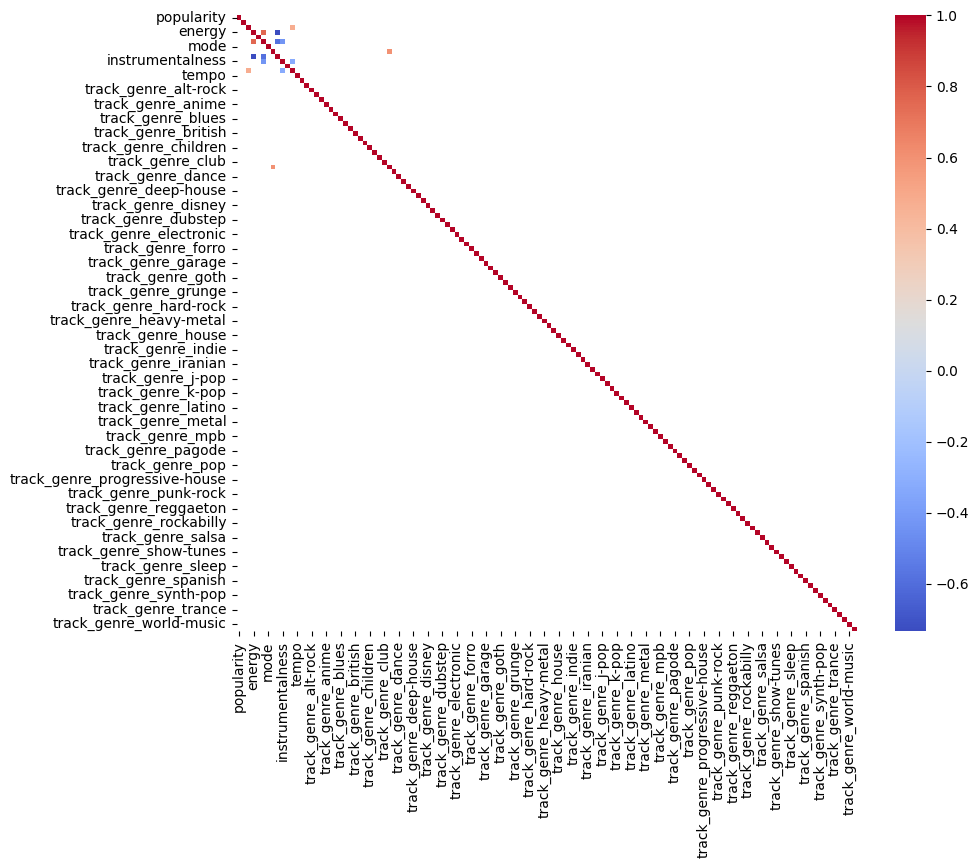

In [ ]:
corr = df_model_scaled.corr()

corr_filtrada = corr[abs(corr) > 0.3]

plt.figure(figsize=(10,8))
sns.heatmap(corr_filtrada, cmap='coolwarm')
plt.show()

Debido a la alta dimensionalidad generada por el encoding de la variable track_genre, se optó por filtrar las variables más relevantes para facilitar la interpretación de la matriz de correlación.

Tras aplicar encoding, se observa que la mayoría de las variables presentan correlaciones débiles con la popularidad, lo que indica que esta no depende de una sola característica. Algunos géneros muestran una leve relación positiva o negativa, pero en general la influencia es baja. Además, variables como danceability y loudness presentan relaciones entre sí, reflejando patrones musicales esperados.

# **Conclusión**

El análisis exploratorio de datos (EDA) permitió comprender la estructura, calidad y comportamiento del dataset de canciones de Spotify, evidenciando que se trata de un conjunto de datos prácticamente limpio, con muy pocos valores nulos. A nivel descriptivo, se observó que predominan canciones con alta energía, baja presencia de contenido hablado y escasa instrumentalidad, lo que sugiere un dominio de canciones vocales. Además, las variables presentan distribuciones concentradas en ciertos rangos y algunos valores atípicos, especialmente en la duración. En cuanto a las variables categóricas, se identificaron desbalances importantes, como en explicit, y distribuciones específicas en variables como key, mode y time_signature. Con el fin de profundizar el análisis, se incorporó una amplia variedad de visualizaciones, permitiendo observar los datos desde distintas perspectivas y reforzar la interpretación de los patrones identificados.

Respecto a la variable objetivo (popularity), los distintos análisis realizados muestran que no existe una relación lineal fuerte con las características musicales, lo que indica que su comportamiento es complejo y probablemente influenciado por factores externos no presentes en el dataset. Finalmente, la aplicación de One Hot Encoding permitió transformar variables categóricas para su uso en análisis posteriores, confirmando que, incluso tras estas transformaciones, la popularidad no puede explicarse por una sola variable. En conjunto, el EDA permitió identificar patrones relevantes, reconocer limitaciones en la capacidad explicativa de las variables y dejar los datos preparados para futuras etapas de modelamiento.

------------------
------------
-------------

# Evaluación 2 — Árbol de Decisión

## Introducción

En esta etapa se aplicará un modelo de clasificación utilizando Árbol de Decisión sobre el dataset de Spotify previamente analizado durante el EDA.

El objetivo es clasificar canciones según niveles de popularidad utilizando características musicales y variables categóricas transformadas mediante técnicas de preprocesamiento.

El modelo fue seleccionado debido a su capacidad para trabajar con relaciones no lineales, variables numéricas y categóricas, además de facilitar la interpretación visual de decisiones dentro del dataset.



# Objetivo General

Aplicar un modelo de Árbol de Decisión para clasificar canciones según su nivel de popularidad a partir de características musicales presentes en el dataset de Spotify.



# Objetivos Específicos

- Preparar los datos para el entrenamiento del modelo.
- Clasificar canciones en categorías de popularidad.
- Evaluar el rendimiento del modelo mediante métricas de clasificación.
- Interpretar los resultados obtenidos.



# Justificación Técnica del Modelo

Se seleccionó el modelo Árbol de Decisión debido a que el dataset contiene variables numéricas y categóricas previamente transformadas mediante One Hot Encoding.

Además, durante el EDA se identificaron relaciones no lineales y correlaciones débiles entre las variables musicales y la popularidad, por lo que un modelo basado en decisiones resulta apropiado para identificar patrones dentro de los datos.

Otra ventaja del modelo es su facilidad de interpretación visual, permitiendo comprender cómo distintas variables influyen en la clasificación de popularidad.

# Modelo arbol de decisión


In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

tomamos las características de las canciones para enseñarle al modelo a clasificar si una canción tiene popularidad baja, media o alta.

In [ ]:
# Variables predictoras
# Quitamos popularity porque es la variable que queremos predecir
X = df_model.drop('popularity', axis=1)

# Variable objetivo
# Convertimos popularity en categorías: Baja, Media y Alta
y = pd.cut(
    df_model['popularity'],
    bins=[0, 30, 60, 100],
    labels=['Baja', 'Media', 'Alta'],
    include_lowest=True
)

# Revisamos cuántos datos hay por categoría
y.value_counts()

,count
popularity,
Baja,51755
Media,48674
Alta,13570


El dataset está relativamente equilibrado entre Baja y Media,
pero la categoría Alta tiene muchos menos datos.

Esto puede hacer que el modelo aprenda mejor las categorías Baja y Media que la categoría Alta.

In [ ]:
# Revisamos si hay valores nulos
print("Nulos en X:", X.isnull().sum().sum())
print("Nulos en y:", y.isnull().sum())

Nulos en X: 126
Nulos en y: 1


Aquí simplemente verificaron si exisitian datos faltantes que puedan causar problemas

In [ ]:
# Unimos X e y para eliminar filas con nulos de forma segura
df_model_final = X.copy()
df_model_final['popularidad_categoria'] = y

# Eliminamos filas con cualquier NaN
df_model_final = df_model_final.dropna()

# Volvemos a separar X e y
X = df_model_final.drop('popularidad_categoria', axis=1)
y = df_model_final['popularidad_categoria']

print("Nulos en X:", X.isnull().sum().sum())
print("Nulos en y:", y.isnull().sum())
print("Tamaño final:", X.shape)

Nulos en X: 0
Nulos en y: 0
Tamaño final: (113998, 127)


limpieamos el dataset para dejar solamente canciones con informacion completa, lista para entrenar ML

In [ ]:
# División de datos: 80% entrenamiento y 20% prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (91198, 127)
Prueba: (22800, 127)


Se realizó una división del dataset en conjuntos de entrenamiento y prueba utilizando la función train_test_split(). El 80% de los datos fue destinado al entrenamiento del modelo y el 20% restante a la evaluación de su rendimiento con datos no vistos previamente.

Además, se utilizó el parámetro random_state=42 para asegurar la reproducibilidad de los resultados, manteniendo siempre la misma división de los datos en cada ejecución.

In [ ]:
# Modelo Árbol de Decisión

modelo_tree = DecisionTreeClassifier(
    max_depth=5,
    criterion="entropy",
    random_state=42
)

# Entrenamiento del modelo
modelo_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

El modelo de Árbol de Decisión fue creado utilizando los parámetros `criterion='entropy'`, `max_depth=5` y `random_state=42`. Posteriormente, el modelo fue entrenado mediante la función `.fit(X_train, y_train)`, utilizando los datos de entrenamiento para aprender patrones y clasificar las canciones en categorías de popularidad baja, media y alta.

In [ ]:
# Predicciones

y_pred = modelo_tree.predict(X_test)

# Primeras predicciones
y_pred[:10]
# En las primeras predicciones el modelo encuentra que todas son bajas
# esto no significa que el modelo este mal
# ahora falta ver las siguientes

array(['Baja', 'Baja', 'Baja', 'Baja', 'Baja', 'Baja', 'Baja', 'Baja',
       'Baja', 'Baja'], dtype=object)

In [ ]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.48846491228070177


este resultado nos muestra que el modelo tiene un 48,8% de acierto
esto significa que de todas las canciones del conjunto el arbol de decisión clasificó correctamente casi la mitad


In [ ]:
# Reporte de clasificación

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Alta       0.61      0.04      0.07      2609
        Baja       0.47      0.99      0.64     10513
       Media       1.00      0.06      0.11      9678

    accuracy                           0.49     22800
   macro avg       0.69      0.36      0.27     22800
weighted avg       0.71      0.49      0.35     22800



El modelo logró clasificar correctamente gran parte de las canciones de popularidad baja, pero presentó dificultades para distinguir canciones de popularidad media y alta. Esto sugiere que las variables musicales disponibles no son suficientes para explicar completamente la popularidad de una canción, ya que probablemente intervienen factores externos como tendencias, marketing o fama del artista.

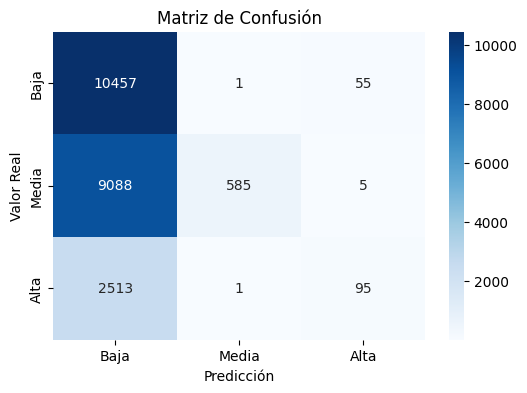

In [ ]:
# Matriz de confusión

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Baja', 'Media', 'Alta']
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Baja', 'Media', 'Alta'],
    yticklabels=['Baja', 'Media', 'Alta']
)

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

La matriz muestra que el modelo clasificó correctamente la mayoría de las canciones de popularidad baja, evidenciado por el valor alto de 10457 en la diagonal principal. Sin embargo, presentó dificultades importantes para distinguir canciones de popularidad media y alta, ya que muchas de ellas fueron clasificadas erróneamente como “Baja”. Por ejemplo, 9088 canciones de popularidad media y 2513 canciones de popularidad alta fueron predichas como bajas. Esto indica que el Árbol de Decisión tiende a favorecer la categoría “Baja”, probablemente debido a que las variables musicales utilizadas no logran separar claramente todos los niveles de popularidad.

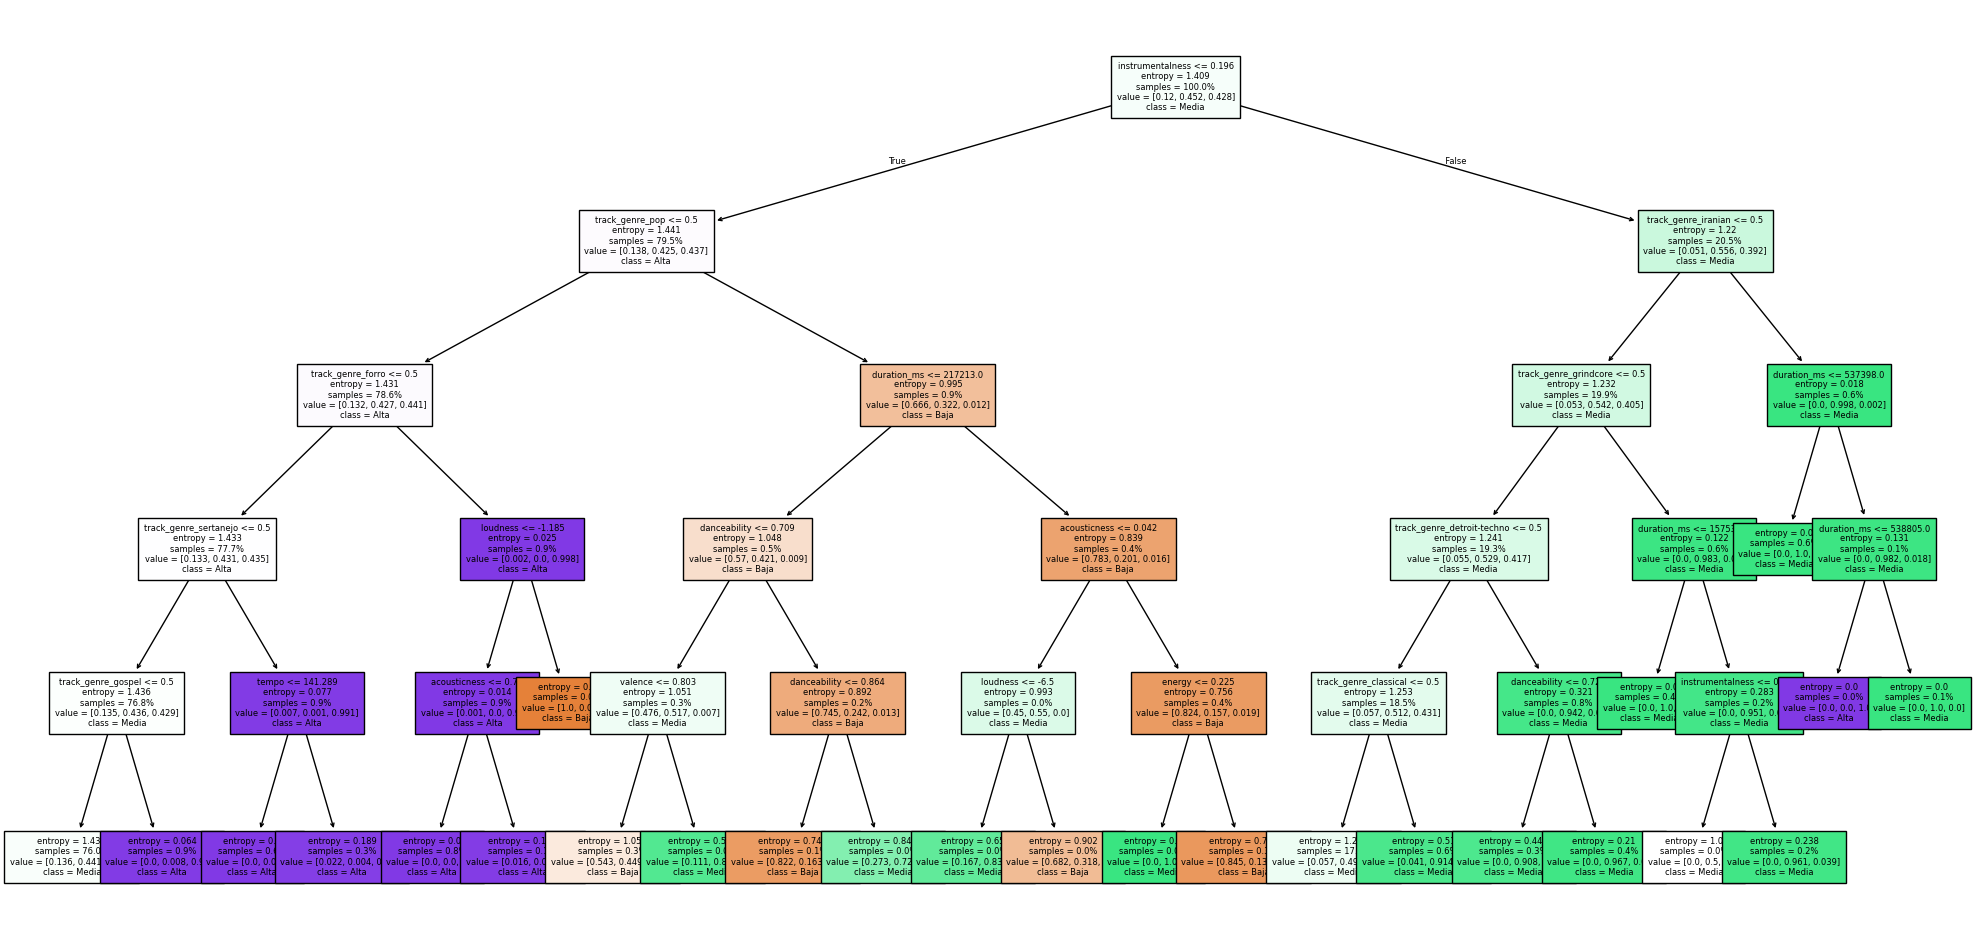

In [ ]:
# Visualización del árbol de decisión

plt.figure(figsize=(25,12))

tree.plot_tree(
    modelo_tree,
    feature_names=X.columns,
    class_names=['Baja', 'Media', 'Alta'],
    label="all",
    proportion=True,
    filled=True,
    fontsize=6
)

plt.show()

Si:
- la canción tiene poca instrumentalidad,
- pertenece a cierto género,
- tiene cierto nivel de energía,
- cierto tempo,
- cierta duración,

Entonces probablemente será Baja, Media o Alta.

El árbol detectó que canciones con baja instrumentalidad (instrumentalness <= 0.20) y pertenecientes al género pop (track_genre_pop > 0.50) tienden en varios casos a clasificarse como “Alta”, especialmente cuando tienen una duración menor a 217213 ms y niveles moderados de danceability.

También se observa que canciones del género gospel (track_genre_gospel > 0.50) fueron clasificadas principalmente como “Media”, mientras que canciones con mayor instrumentalidad (instrumentalness > 0.20) tendieron mayormente a clasificarse como “Baja”.

Además, variables como loudness, energy, acousticness y tempo aparecen constantemente en las decisiones del árbol, lo que indica que el modelo considera múltiples características musicales al momento de clasificar la popularidad de una canción.

# Conclusión
El Árbol de Decisión permitió identificar patrones musicales relacionados con la popularidad, aunque las características disponibles no fueron suficientes para predecir completamente todos los niveles de popularidad. Los resultados sugieren que la popularidad de una canción depende tanto de factores musicales como de factores externos no presentes en el dataset.

El modelo sobreaprendió la clase Baja.

------------------
--------------


# Modelo naive bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Modelo Naive Bayes

modelo_nb = GaussianNB()

In [ ]:
# Entrenamiento

modelo_nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Predicciones con los datos de prueba

y_pred_nb = modelo_nb.predict(X_test)

# Primeras 10 predicciones generadas por el modelo
y_pred_nb[:10]

array(['Media', 'Media', 'Media', 'Baja', 'Media', 'Media', 'Baja',
       'Media', 'Media', 'Media'], dtype='<U5')

In [ ]:
# Accuracy

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb)

Accuracy: 0.4663157894736842


El resultado indica que el modelo logró clasificar correctamente aproximadamente un 46,6% de las canciones del conjunto de prueba.

In [ ]:
# REPORTE DE CLASIFICACIÓN
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

        Alta       0.00      0.00      0.00      2609
        Baja       0.55      0.30      0.39     10513
       Media       0.44      0.78      0.56      9678

    accuracy                           0.47     22800
   macro avg       0.33      0.36      0.32     22800
weighted avg       0.44      0.47      0.42     22800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* precision: qué tan precisas fueron las predicciones del modelo para cada categoría.
* recall: mide qué porcentaje de los datos reales de una categoría logró detectar correctamente el modelo.
* f1-score: combina precision y recall para evaluar el rendimiento general del modelo en cada categoría.
* support: cantidad de registros reales que existen en cada categoría dentro del conjunto de prueba.

Los resultados indican que el modelo tuvo mejor desempeño en la categoría Media, mientras que presentó dificultades para identificar correctamente canciones de popularidad Alta, obteniendo un rendimiento general cercano al 47% de accuracy.

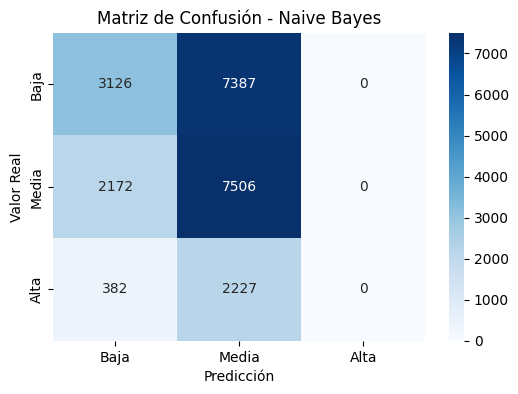

In [ ]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=['Baja', 'Media', 'Alta']
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Baja', 'Media', 'Alta'],
    yticklabels=['Baja', 'Media', 'Alta']
)

plt.title('Matriz de Confusión - Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

In [ ]:
pd.Series(y_pred_nb).value_counts()

,count
Media,17120
Baja,5680


El modelo Naive Bayes obtuvo un accuracy aproximado de 46,6%, presentando un rendimiento inferior al Árbol de Decisión. A partir de la matriz de confusión y del classification report, se observó que el modelo no logró predecir correctamente canciones de popularidad alta, clasificando la mayoría de los casos como “Media” o “Baja”. Esto indica que las relaciones entre las variables musicales son más complejas de lo que Naive Bayes puede modelar adecuadamente, debido a que muchas características musicales se encuentran relacionadas entre sí y no cumplen completamente el supuesto de independencia probabilística del modelo.

-----------------

# K-means

* ¿Existen tipos de canciones similares?
* ¿Qué perfiles musicales aparecen?
* ¿Hay grupos de canciones energéticas?
* ¿Hay clusters de canciones instrumentales?
* ¿Existen grupos asociados a ciertos géneros?
* ¿Qué características dominan cada cluster?

In [ ]:
# Variables utilizadas en K-Means

features_kmeans = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

## Variables descartadas del dataset para K-Means

Las siguientes variables fueron descartadas del análisis K-Means debido a que corresponden a variables categóricas, identificadores o texto, las cuales no son adecuadas para el cálculo de distancias euclidianas utilizado por el algoritmo.

variables_descartadas =
* 'Unnamed: 0'
* 'track_id'
* 'artists'
* 'album_name'
* 'track_name'
* 'popularity'
* 'explicit'          # Variable binaria
* 'key'               # Variable categórica nominal
* 'mode'              # Variable binaria
* 'time_signature'    # Variable categórica discreta
* 'track_genre'


In [ ]:
# Creamos la matriz solo con las variables seleccionadas

X = df[features_kmeans]

print(X.shape)
X.head()

(113999, 10)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853


escalamos los datos

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalamos los datos
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(113999, 10)


En esta etapa los datos son transformados para que todas las variables queden en una escala similar, con media cercana a 0 y desviación estándar cercana a 1. Esto ayuda a mejorar el rendimiento.

In [ ]:
!pip install kneed

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# 4. Método del Codo + Silhouette

In [ ]:
sse = []
silhouette_scores = []

rango_k = range(2, 11)

print("Calculando métricas...")

for k in rango_k:

    kmeans_eval = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans_eval.fit(X_scaled)

    labels = kmeans_eval.labels_

    sse.append(kmeans_eval.inertia_) #metodo codo

    #metodo
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

# Detectar codo automático
kl = KneeLocator(
    rango_k,
    sse,
    curve="convex",
    direction="decreasing"
)

print("El codo está en k =", kl.elbow)

Calculando métricas...
El codo está en k = 6


Se evaluaron distintos valores de k utilizando el algoritmo K-Means con el objetivo de determinar la cantidad óptima de clusters. Para cada valor de k se calcularon métricas como el SSE (Sum of Squared Errors) y el Silhouette Score, permitiendo analizar la calidad del agrupamiento. Finalmente, mediante el método del codo (KneeLocator), se identificó automáticamente el valor más adecuado de clusters para el modelo.

usar k = 6 como cantidad óptima de clusters según el método del codo.

In [ ]:
print("Puntaje Silhouette:")

for k, score in zip(rango_k, silhouette_scores):
    print(f"k={k}: {score:.4f}")

Puntaje Silhouette:
k=2: 0.2506
k=3: 0.1558
k=4: 0.1617
k=5: 0.1663
k=6: 0.1667
k=7: 0.1777
k=8: 0.1790
k=9: 0.1808
k=10: 0.1653


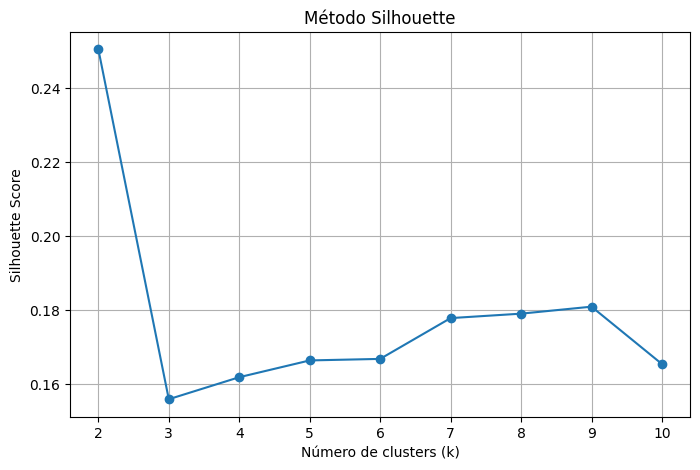

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(rango_k, silhouette_scores, marker='o')

plt.title('Método Silhouette')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')

plt.grid(True)
plt.show()

Aquí se muestran los valores del Silhouette Score para cada cantidad de clusters (k), permitiendo evaluar la calidad del agrupamiento generado por K-Means. Valores más altos indican clusters mejor definidos y separados.

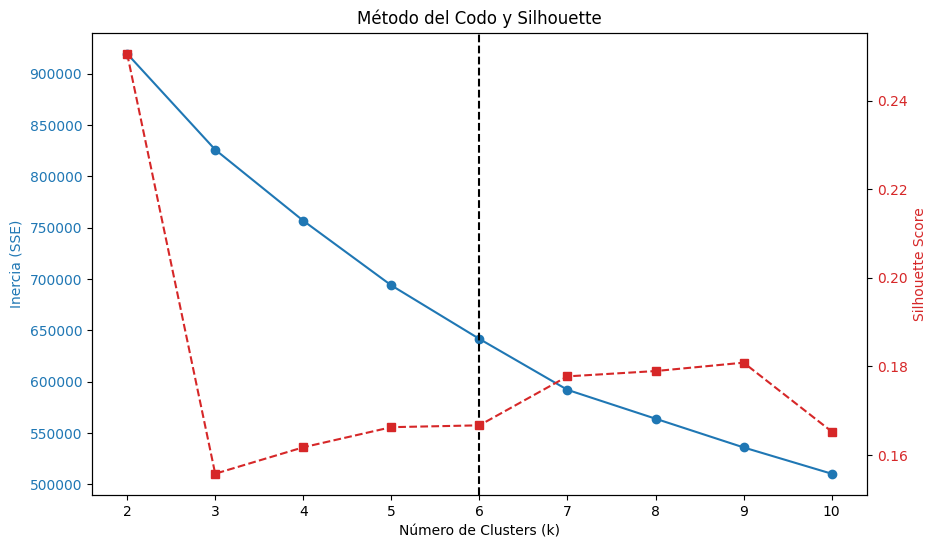

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Grafico del codo
color = 'tab:blue'

ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (SSE)', color=color)

ax1.plot(
    rango_k,
    sse,
    marker='o',
    color=color
)

if kl.elbow:
    ax1.axvline(
        x=kl.elbow,
        color='black',
        linestyle='--',
        label=f'Codo detectado (k={kl.elbow})'
    )

ax1.tick_params(axis='y', labelcolor=color)

# Silhouette
ax2 = ax1.twinx()

color = 'tab:red'

ax2.set_ylabel('Silhouette Score', color=color)

ax2.plot(
    rango_k,
    silhouette_scores,
    marker='s',
    linestyle='--',
    color=color
)

ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo y Silhouette')

plt.show()

In [ ]:
modelo_kmeans = KMeans(
    n_clusters=6,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

modelo_kmeans.fit(X_scaled)

df['cluster'] = modelo_kmeans.labels_

Aquí se creó y entrenó el modelo K-Means utilizando 6 clusters, definidos previamente mediante el método del codo. Posteriormente, el modelo agrupó las canciones según características similares y asignó a cada registro una etiqueta de cluster, almacenándola en la nueva columna cluster del DataFrame.

In [ ]:
df['cluster'].value_counts().sort_index()

,count
cluster,
0,7882
1,23348
2,36852
3,26921
4,11535
5,7461


El método del codo identificó 6 clusters como punto óptimo de segmentación. Por otro lado, el método Silhouette alcanzó su mayor valor en k=9; sin embargo, las diferencias entre los valores de silhouette fueron relativamente pequeñas a partir de k=6. Debido a esto, se decidió utilizar 6 clusters, priorizando un modelo más interpretable y consistente con el método del codo.

Se logró aplicar correctamente el modelo K-Means utilizando 6 clusters, valor obtenido mediante el método del codo. Los resultados muestran que las canciones fueron distribuidas de forma relativamente equilibrada entre los distintos grupos, aunque algunos clusters concentran una mayor cantidad de registros que otros.

El cluster 2 fue el más grande con 36.852 canciones, seguido por el cluster 3 con 26.921 y el cluster 1 con 23.348 canciones. Por otro lado, los clusters 0 y 5 fueron los más pequeños, con 7.882 y 7.461 canciones respectivamente. Esto indica que existen ciertos grupos predominantes dentro del dataset, mientras que otros presentan menor frecuencia de aparición.

En conjunto, los resultados demuestran que K-Means logró segmentar el dataset en 6 grupos diferenciados, evidenciando la existencia de patrones naturales en las características musicales de las canciones.



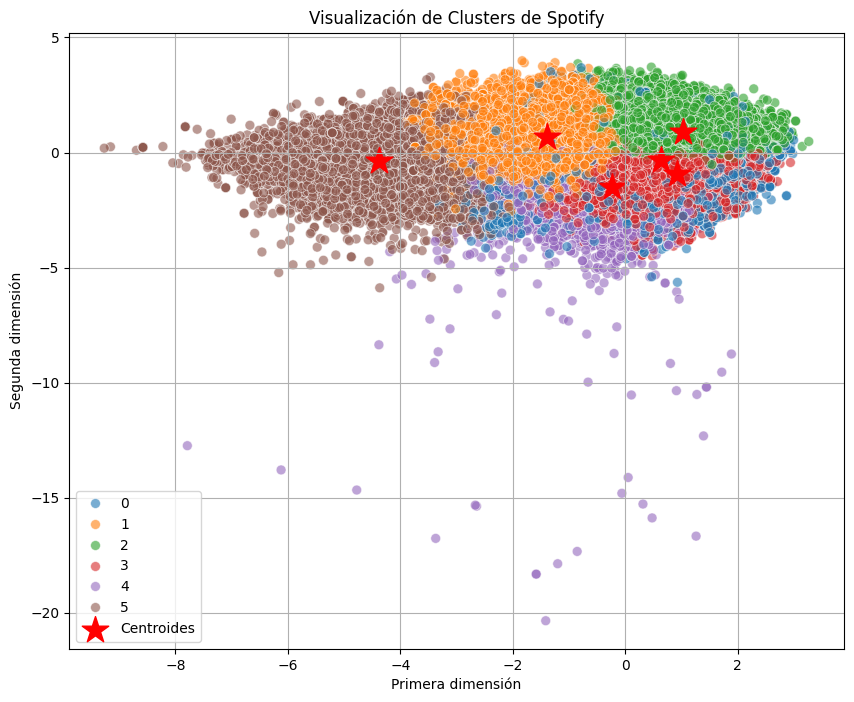

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

datos_2d = pca.fit_transform(X_scaled)

centroides_2d = pca.transform(modelo.cluster_centers_)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=datos_2d[:,0],
    y=datos_2d[:,1],
    hue=modelo.labels_,
    palette='tab10',
    alpha=0.6,
    s=50
)

plt.scatter(
    centroides_2d[:,0],
    centroides_2d[:,1],
    c='red',
    marker='*',
    s=400,
    label='Centroides'
)

plt.title('Visualización de Clusters de Spotify')
plt.xlabel('Primera dimensión')
plt.ylabel('Segunda dimensión')

plt.legend()
plt.grid(True)

plt.show()

Aquí se utilizó PCA para reducir las variables del dataset a dos dimensiones y poder visualizar gráficamente los clusters generados por K-Means. Cada color representa un cluster distinto y las estrellas rojas corresponden a los centroides de cada grupo.


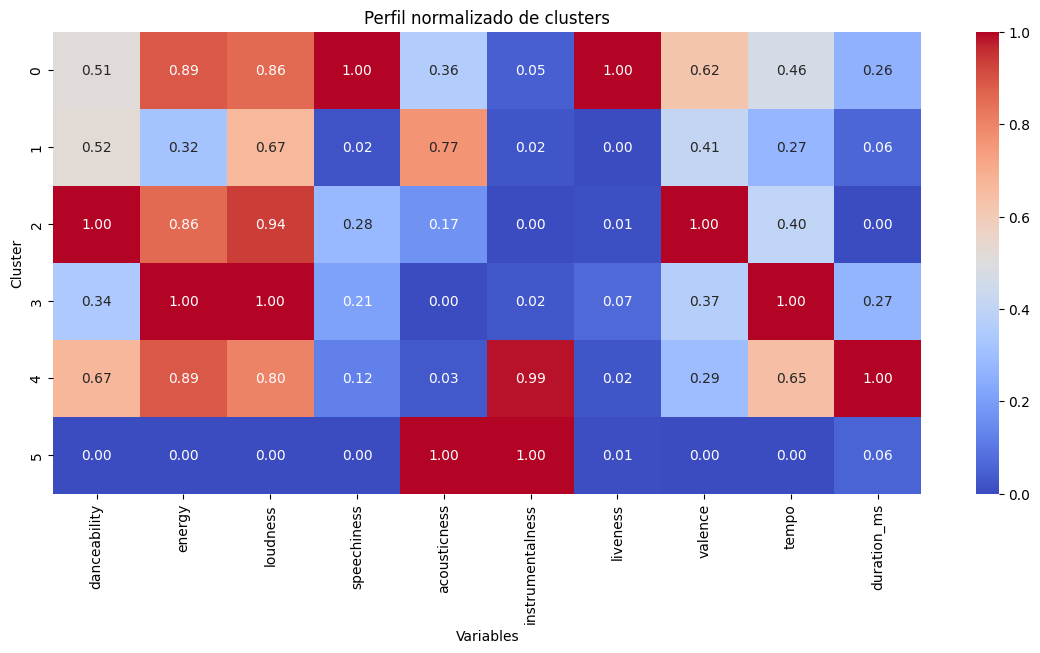

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar centroides para visualización
scaler_vis = MinMaxScaler()

cluster_scaled = pd.DataFrame(
    scaler_vis.fit_transform(cluster_summary),
    columns=cluster_summary.columns,
    index=cluster_summary.index
)

plt.figure(figsize=(14,6))

sns.heatmap(
    cluster_scaled,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title('Perfil normalizado de clusters')
plt.xlabel('Variables')
plt.ylabel('Cluster')

plt.show()

## Cluster 0: Canciones energéticas y tipo “en vivo”

- `energy` alta  
- `loudness` alta  
- `speechiness` muy alta  
- `liveness` máxima  

### Interpretación
Canciones intensas, con presencia vocal marcada y fuerte sensación de grabación en vivo.

---

## Cluster 1: Canciones acústicas y tranquilas

- `acousticness` alta  
- `energy` baja  
- `tempo` bajo  
- `instrumentalness` baja  

### Interpretación
Música suave, acústica y más relajada.

---

## Cluster 2: Canciones bailables y alegres

- `danceability` máxima  
- `valence` máxima  
- `energy` alta  

### Interpretación
Canciones comerciales, alegres y muy bailables.

---

## Cluster 3: Canciones rápidas e intensas

- `energy` máxima  
- `loudness` máxima  
- `tempo` máximo  

### Interpretación
Canciones rápidas, fuertes y dinámicas.

---

## Cluster 4: Música instrumental extensa

- `instrumentalness` muy alta  
- `duration_ms` máxima  
- `energy` alta  

### Interpretación
Canciones instrumentales y de mayor duración.

---

## Cluster 5: Canciones ambientales y muy suaves

- `acousticness` máxima  
- `instrumentalness` máxima  
- `energy` mínima  
- `loudness` mínima  

### Interpretación
Música lenta, ambiental, relajante o instrumental.

# Conclusión
el modelo K-Means permitió identificar distintos perfiles de canciones dentro del dataset de Spotify, agrupando temas con características musicales similares. Los clusters obtenidos muestran diferencias claras en variables como energía, instrumentalidad, tempo, danceability y acousticness, permitiendo distinguir grupos de canciones energéticas, acústicas, bailables, instrumentales y ambientales.

Esto demuestra que el algoritmo logró segmentar correctamente las canciones según patrones musicales relevantes, facilitando el análisis e interpretación de distintos estilos y comportamientos dentro del conjunto de datos.


# Conclusión general

Los modelos aplicados permitieron abordar el dataset desde distintos enfoques de Machine Learning. Los modelos supervisados, Árbol de Decisión y Naive Bayes, fueron utilizados para clasificar canciones según su nivel de popularidad (`Baja`, `Media` y `Alta`). Entre ambos, el Árbol de Decisión obtuvo un mejor rendimiento, alcanzando un accuracy cercano al 49%, mientras que Naive Bayes logró aproximadamente un 47%, mostrando mayores dificultades para identificar correctamente canciones de popularidad alta.

Por otro lado, K-Means permitió realizar un análisis no supervisado, agrupando canciones según características musicales similares sin utilizar etiquetas de popularidad. A través de este modelo fue posible identificar distintos perfiles musicales, como canciones energéticas, acústicas, bailables o instrumentales, facilitando la segmentación e interpretación del comportamiento del dataset.
